## Mindfulness and User Experience Using Calm And Headspace
### RQ1: What are the primary themes and topics of discussion within user reviews for top mindfulness apps, and what is the overall sentiment associated with each app?
### RQ2: What specific features or aspects of the apps are the primary drivers of positive and negative user sentiment?
### RQ3: What are the core user needs that drive users to these apps, and how effectively is each app succeeding or failing in addressing them?

**Steps:**
1. Scraping [Google Play Store](#Scraping-Android-Reviews-(Google-Play-Store)) and [Apple App Store](#Scraping-Apple-App-Store-Reviews) for Calm and Headspace Reviews, two of the most popular mindfulness apps
2. [Wrangling](#Wrangling-Data) the Data
3. [Early Sentiment Analysis](#Early-Sentiment-Analysis) with **VADER**
    * [Statistical Analysis](#Statistical-Analysis) of the Data Throughout
4. [Topic Modeling](#Topic-Modeling:-BERTopic) with **BERTopic**
    * [Strategic Analysis: Comparison](#Strategic-Analysis:-Comparison)
    * [Strategic Analysis: Voice of the User](#Strategic-Analysis:-Voice-of-the-User) 
    * [Topic Modeling Overview](#Topic-Modeling-Overview)
5.  [Sentiment Analysis](#ABSA) with **ABSA**
    * [ABSA Overview I](#Overview:-App-Stability-&-The-Q1-Bug-Surge)
    * [ABSA Overview II](#The-Counterweight:-Profound-Real-World-Impact)

<a id="google-reviews"></a>

### Scraping Reviews

### Scraping Android Reviews (Google Play Store)
**Scraping Google Play Store Reviews for Headspace and Calm.**

I scraped reviews over a few months. 

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [2]:
!pip install google_play_scraper

In [3]:
from google_play_scraper import reviews, Sort
import pandas as pd

# 1. Correcting App IDs
APP_PACKAGES = {
    "Calm": "com.calm.android",
    "Headspace": "com.getsomeheadspace.android"
}

print(" Starting Google Play Store Scrape ")

#  2. Looping Through Apps
for app_name, app_id in APP_PACKAGES.items():
    print(f"Scraping reviews for: {app_name} (ID: {app_id})")

    try:
        # The 'reviews' function returns the reviews list and a token I don't need.
        result, _ = reviews(
            app_id,
            lang='en',
            country='us',
            sort=Sort.NEWEST,
            count=1000,          # Get 1000 reviews
            filter_score_with=None # Ensures I get reviews of all star ratings
        )

        #  3. Checking for Results and Saving
        if result:
            print(f"  Found {len(result)} reviews for {app_name}.")
            df = pd.DataFrame(result)

            # Adding the app name as a new column for easier analysis later
            df.insert(0, 'app_name', app_name)

            # Using the friendly app name for the CSV file
            file_name = f"{app_name}_Google_Play_reviews.csv"
            df.to_csv(file_name, index=False, encoding='utf-8-sig')
            print(f"Successfully saved reviews to '{file_name}'")
        else:
            print(f"No reviews were found for {app_name}. No file was created.")

    except Exception as e:
        # This will catch any errors if an app ID is truly invalid or there's a network issue.
        print(f"An error occurred while scraping {app_name}: {e}")

print(" All scraping complete. ")


 Starting Google Play Store Scrape 
Scraping reviews for: Calm (ID: com.calm.android)
  Found 1000 reviews for Calm.
Successfully saved reviews to 'Calm_Google_Play_reviews.csv'
Scraping reviews for: Headspace (ID: com.getsomeheadspace.android)
  Found 1000 reviews for Headspace.
Successfully saved reviews to 'Headspace_Google_Play_reviews.csv'
 All scraping complete. 


### Scraping Apple App Store Reviews
**It took several attempts to scrape Apple reviews: I deleted the code that did not work to save space.
<br> This task was complex as you need to use the mobile App Store to see all reviews, and the browser version of the App Store only shows a preview of 10 reviews for an app. You can only get full access to reviews from specific dates by paying for an API key through Apple Developers. 

I scraped reviews over a few months

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [ ]:
%pip install requests

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install selenium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 7.9 MB/s  0:00:01m 8.0 MB/s eta 0:00:01
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.25.11
    Uninstalling urllib3-1.25.11:
      Successfully uninstalled urllib3-1.25.11
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [selenium]━━ 6/7 [selenium]io]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
requests 2.23.0 requires urllib3!=1.25.0,!=1.25.1,<1.26,>=1.21.1, but you have urllib3 2.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install --upgrade selenium


Note: you may need to restart the kernel to use updated packages.


In [5]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET # Python's built-in XML parser

#  1. Defining Targets
APP_IDS = {
    "Calm": "571800810",
    "Headspace": "493145008"
}

# XML has "namespaces" to handle
NAMESPACES = {
    'atom': 'http://www.w3.org/2005/Atom',
    'im': 'http://itunes.apple.com/rss'
}

#  2. Looping through each app
for app_name, app_id in APP_IDS.items():
    print(f"\n{'='*50}")
    print(f" Starting scrape for: {app_name} ")

    all_reviews = []
    # Loop through pages 1 to 10 (Apple provides 10 pages of 50 reviews each)
    for page in range(1, 11):
        # Construct the RSS feed URL
        url = f"https://itunes.apple.com/us/rss/customerreviews/page={page}/id={app_id}/sortBy=mostRecent/xml"
        print(f"Fetching page {page} for {app_name}...")

        try:
            response = requests.get(url)
            # Check if the request was successful
            print(f"  Response Status Code: {response.status_code}")
            response.raise_for_status() # Raise an error for bad status codes (4xx or 5xx)
        except requests.exceptions.RequestException as e:
            print(f"  ERROR: Could not fetch page {page}. Error: {e}")
            continue # Skip to the next page

        #  3. Parsing the XML data
        try:
            # Parsing the XML string from the response content
            root = ET.fromstring(response.content)

            # Finding all 'entry' tags. Each 'entry' is a single review.
            entries = root.findall('atom:entry', NAMESPACES)
            print(f"  Found {len(entries)} review entries on this page.")

            # If the feed only contains the header/link and no actual reviews, stop.
            if len(entries) <= 1:
                print("  No more unique reviews found. Stopping for this app.")
                break

            for entry in entries:
                # FIXING: Now correctly passing the NAMESPACES to this 'find' call.
                # Skipping the very first 'entry' as it's just a link to the feed itself.
                if entry.find('atom:author', NAMESPACES) is None:
                    continue

                try:
                    title = entry.find('atom:title', NAMESPACES).text
                    author = entry.find('atom:author/atom:name', NAMESPACES).text
                    rating = entry.find('im:rating', NAMESPACES).text
                    content = entry.find('atom:content[@type="text"]', NAMESPACES).text

                    all_reviews.append({
                        'app_name': app_name,
                        'author': author,
                        'rating': rating,
                        'title': title,
                        'review_text': content,
                    })
                except AttributeError:
                    # This catches rare cases where a review might be missing a field
                    print("  - Skipped a review entry with missing data.")

        except ET.ParseError as e:
            print(f"  ERROR: Could not parse XML from page {page}. Error: {e}")
            print(f"  Response Text: {response.text[:300]}...") # Print the start of the response
            continue

    print(f"Total reviews scraped for {app_name}: {len(all_reviews)}")

    #  4. Saving to CSV
    if all_reviews:
        reviews_df = pd.DataFrame(all_reviews)
        file_name = f"{app_name}_Apple_reviews_RSS.csv"
        reviews_df.to_csv(file_name, index=False, encoding='utf-8-sig')
        print(f"Successfully saved reviews to '{file_name}' ")
    else:
        print(f"No reviews were scraped for {app_name}. No file saved.")

print(f"\n{'='*50}")
print("All scraping complete. ")




 Starting scrape for: Calm 
Fetching page 1 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 2 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 3 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 4 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 5 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 6 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 7 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 8 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 9 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 10 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Total revi

In [6]:
import requests
import pandas as pd
import xml.etree.ElementTree as ET # Python's built-in XML parser

#  1. Defining Targets
APP_IDS = {
    "Calm": "571800810",
    "Headspace": "493145008"
}

# XML has "namespaces" to handle
NAMESPACES = {
    'atom': 'http://www.w3.org/2005/Atom',
    'im': 'http://itunes.apple.com/rss'
}

#  2. Looping through each app
for app_name, app_id in APP_IDS.items():
    print(f"\n{'='*50}")
    print(f" Starting scrape for: {app_name} ")

    all_reviews = []
    # Loop through pages 1 to 10 (Apple provides 10 pages of 50 reviews each)
    for page in range(1, 11):
        # Construct the RSS feed URL
        url = f"https://itunes.apple.com/us/rss/customerreviews/page={page}/id={app_id}/sortBy=mostRecent/xml"
        print(f"Fetching page {page} for {app_name}...")

        try:
            response = requests.get(url)
            # Check if the request was successful
            print(f"  Response Status Code: {response.status_code}")
            response.raise_for_status() # Raise an error for bad status codes (4xx or 5xx)
        except requests.exceptions.RequestException as e:
            print(f"  ERROR: Could not fetch page {page}. Error: {e}")
            continue # Skip to the next page

        #  3. Parsing the XML data
        try:
            # Parsing the XML string from the response content
            root = ET.fromstring(response.content)

            # Finding all 'entry' tags. Each 'entry' is a single review.
            entries = root.findall('atom:entry', NAMESPACES)
            print(f"  Found {len(entries)} review entries on this page.")

            # If the feed only contains the header/link and no actual reviews, stop.
            if len(entries) <= 1:
                print("  No more unique reviews found. Stopping for this app.")
                break

            for entry in entries:
                # FIXING: Now correctly passing the NAMESPACES to this 'find' call.
                # Skipping the very first 'entry' as it's just a link to the feed itself.
                if entry.find('atom:author', NAMESPACES) is None:
                    continue

                try:
                    title = entry.find('atom:title', NAMESPACES).text
                    author = entry.find('atom:author/atom:name', NAMESPACES).text
                    rating = entry.find('im:rating', NAMESPACES).text
                    content = entry.find('atom:content[@type="text"]', NAMESPACES).text

                    all_reviews.append({
                        'app_name': app_name,
                        'author': author,
                        'rating': rating,
                        'title': title,
                        'review_text': content,
                    })
                except AttributeError:
                    # This catches rare cases where a review might be missing a field
                    print("  - Skipped a review entry with missing data.")

        except ET.ParseError as e:
            print(f"  ERROR: Could not parse XML from page {page}. Error: {e}")
            print(f"  Response Text: {response.text[:300]}...") # Print the start of the response
            continue

    print(f"Total reviews scraped for {app_name}: {len(all_reviews)}")

    #  4. Saving to CSV
    if all_reviews:
        reviews_df = pd.DataFrame(all_reviews)
        file_name = f"{app_name}_Apple_reviews_RSS.csv"
        reviews_df.to_csv(file_name, index=False, encoding='utf-8-sig')
        print(f"Successfully saved reviews to '{file_name}' ")
    else:
        print(f"No reviews were scraped for {app_name}. No file saved.")

print(f"\n{'='*50}")
print("All scraping complete. ")


 Starting scrape for: Calm 
Fetching page 1 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 2 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 3 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 4 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 5 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 6 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 7 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 8 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 9 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Fetching page 10 for Calm...
  Response Status Code: 200
  Found 50 review entries on this page.
Total revi

# Wrangling Data

# RQ1: What are the primary themes and topics of discussion within user reviews for top mindfulness apps, and what is the overall sentiment associated with each app?

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [10]:
import pandas as pd
import glob

# 1. Finding and Loading All Review CSV Files

all_files = glob.glob("*_reviews*.csv")

if not all_files:
    print("Error: No CSV files found matching the '*_reviews*.csv' pattern.")
else:
    print(f"Found {len(all_files)} files to process: {all_files}")

    list_of_dfs = []
    for f in all_files:
        try:
            df = pd.read_csv(f)
            list_of_dfs.append(df)
            print(f"  - Successfully loaded '{f}' with {len(df)} rows.")
        except Exception as e:
            print(f"  - Failed to load or process '{f}': {e}")

Found 14 files to process: ['Jan_Headspace_Apple_reviews.csv', 'Jan_Calm_Apple_reviews.csv', 'Jan_Headspace_Google_Play_reviews.csv', 'Mar_Headspace_Apple_reviews.csv', 'Nov_Calm_Apple_reviews.csv', 'Dec_Headspace_Apple_reviews.csv', 'Mar_Calm_Apple_reviews.csv', 'Jan_Calm_Google_Play_reviews.csv', 'Dec_Calm_Apple_reviews.csv', 'Mar_Calm_Google_Play_reviews.csv', 'Nov_Headspace_Google_Play_reviews.csv', 'Nov_Headspace_Apple_reviews.csv', 'Nov_Calm_Google_Play_reviews.csv', 'Mar_Headspace_Google_Play_reviews.csv']
  - Successfully loaded 'Jan_Headspace_Apple_reviews.csv' with 500 rows.
  - Successfully loaded 'Jan_Calm_Apple_reviews.csv' with 500 rows.
  - Successfully loaded 'Jan_Headspace_Google_Play_reviews.csv' with 1000 rows.
  - Successfully loaded 'Mar_Headspace_Apple_reviews.csv' with 500 rows.
  - Successfully loaded 'Nov_Calm_Apple_reviews.csv' with 500 rows.
  - Successfully loaded 'Dec_Headspace_Apple_reviews.csv' with 500 rows.
  - Successfully loaded 'Mar_Calm_Apple_review

In [43]:
import pandas as pd
import os

cleaned_dfs = []

# This dictionary maps the string in the filename to the correct month of the reviews
month_mapping = {
    'nov': 11,
    'dec': 12,
    'jan': 1,
    'mar': 3
}

# 1 & 2. Loading, Standardizing, and Checking Filenames
for file in all_files:
    # Read the CSV
    df = pd.read_csv(file)
    temp_df = pd.DataFrame()
    
    # I get the filename and make it lowercase to easily check for my keywords
    filename = os.path.basename(file).lower()
    
    temp_df['app_name'] = df['app_name']

    # Setting the platform
    if 'google' in filename:
        temp_df['source'] = 'Google Play'
        temp_df['review'] = df['content']
        temp_df['rating'] = df['score']
    elif 'apple' in filename:
        temp_df['source'] = 'Apple App Store'
        temp_df['review'] = df['review_text']
        temp_df['rating'] = df['rating']

    # Setting the month number
    temp_df['month_number'] = None 
    for month_abbr, month_num in month_mapping.items():
        if month_abbr in filename:
            temp_df['month_number'] = month_num
            break 

    cleaned_dfs.append(temp_df)
        
# 3. Creating and Inspecting Master DataFrame
if cleaned_dfs:
    master_df = pd.concat(cleaned_dfs, ignore_index=True)
    master_df.dropna(subset=['review'], inplace=True)
    master_df['rating'] = master_df['rating'].astype(int)

    print("Successfully created master DataFrame!")
    
    print("\nReview counts per app and source:")
    display(master_df.groupby(['app_name', 'source']).size().unstack(fill_value=0))

    # Saving the master file
    output_filename = "Multi_Month_App_Reviews.csv"
    master_df.to_csv(output_filename, index=False)
    print(f"\nSaved combined data to '{output_filename}'.")
else:
    print("No files were processed.")

Successfully created master DataFrame!

Review counts per app and source:


source,Apple App Store,Google Play
app_name,,
Calm,2000,3000
Headspace,2000,3000



Saved combined data to 'Multi_Month_App_Reviews.csv'.


# Early-Sentiment-Analysis

## RQ1: Pre-processing and using VADER to calculate overall sentiment. 

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [69]:
import pandas as pd

# 1. Loading the current dataset
df = pd.read_csv("Multi_Month_App_Reviews.csv")
print(f"Original row count: {len(df)}")

# 2. Dropping duplicates
# We check for duplicates based on the actual review text, app name, and rating.
# keep='first' means it keeps the earliest instance of the review and drops the rest.
df_clean = df.drop_duplicates(subset=['review', 'app_name', 'rating', 'source'], keep='first').copy()

print(f"New row count after removing duplicates: {len(df_clean)}")
print(f"Total duplicates removed: {len(df) - len(df_clean)}")

# 3. Saving the clean version!
df_clean.to_csv("Multi_Month_App_Reviews_CLEANED.csv", index=False)
print("Saved as 'Multi_Month_App_Reviews_CLEANED.csv'")

Original row count: 10000
New row count after removing duplicates: 5564
Total duplicates removed: 4436
Saved as 'Multi_Month_App_Reviews_CLEANED.csv'


I realized that I had duplicates in my reviews. While I obtained my reviews during separate months, some reviews were still "most recent," so they were captured in that month's scrape. This greatly reduced my data count from 10,000 reviews to 5,564 reviews.

In [70]:
# See the total count per app
print("--- Reviews per App ---")
print(df_clean['app_name'].value_counts())
print("\n")

# To get even more granular, let's see the breakdown by App AND Source (Apple vs Google)
print("--- Reviews per App by Source ---")
print(df_clean.groupby(['app_name', 'source']).size())


--- Reviews per App ---
app_name
Calm         3002
Headspace    2562
Name: count, dtype: int64


--- Reviews per App by Source ---
app_name   source         
Calm       Apple App Store    1181
           Google Play        1821
Headspace  Apple App Store     701
           Google Play        1861
dtype: int64


**The good news is, things are fairly even.!**

In [71]:
import pandas as pd
import re
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# VADER
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except nltk.downloader.DownloadError:
    print("Downloading VADER lexicon...")
    nltk.download('vader_lexicon')

# 1. Loading combined data
try:
    df = pd.read_csv("Multi_Month_App_Reviews_CLEANED.csv")
    df['review'] = df['review'].astype(str).fillna('')
    print("Successfully loaded 'Multi_Month_App_Reviews_CLEANED.csv'.")
except FileNotFoundError:
    print("Error: 'Multi_Month_App_Reviews_CLEANED.csv' not found. Please run the combination script first.")
    exit()

Successfully loaded 'Multi_Month_App_Reviews_CLEANED.csv'.


In [72]:
# 2. Defining and Deciding on a Light Cleaning Function for VADER (Pre-Processing)
def light_clean_for_vader(text):
    """
    This function performs minimal cleaning for VADER analysis.
    - Removes URLs
    - Removes HTML tags
    - Replaces multiple whitespace characters with a single space
    - It deliberately DOES NOT convert to lowercase, remove stop words, or remove punctuation.
    """
    # Removing URLs (http/https links)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Removing HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Replacing multiple whitespace characters with a single space and strip leading/trailing space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [73]:
# 3. Applying Cleaning and Initializing VADER
# New column for the cleaned text
df['cleaned_review'] = df['review'].apply(light_clean_for_vader)

# Initializing the Sentiment Intensity Analyzer
sia = SentimentIntensityAnalyzer()

print("Running VADER sentiment analysis on cleaned reviews...")
# Applying VADER to the new 'cleaned_review' column
df['sentiment_scores'] = df['cleaned_review'].apply(lambda review: sia.polarity_scores(review))

Running VADER sentiment analysis on cleaned reviews...


## You can see sentiment category scores here

In [74]:
# 4. Extracting Scores and Creating Sentiment Categories
df['compound_score'] = df['sentiment_scores'].apply(lambda d: d.get('compound', 0))
df['positive_score'] = df['sentiment_scores'].apply(lambda d: d.get('pos', 0))
df['neutral_score'] = df['sentiment_scores'].apply(lambda d: d.get('neu', 0))
df['negative_score'] = df['sentiment_scores'].apply(lambda d: d.get('neg', 0))

def get_sentiment_category(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['compound_score'].apply(get_sentiment_category)

In [75]:
# 5. Reviewing the Results and Saving Data
print(" VADER Sentiment Analysis Complete! :) ")
print("Comparing original review, cleaned review, and sentiment scores:")
# Displaying columns to see the effect of cleaning
display(df[['review', 'cleaned_review', 'compound_score', 'sentiment_category']].head())

print("Sentiment category distribution:")
display(df['sentiment_category'].value_counts())

# Saving the final, analysis-ready file
final_output_filename = "Multi_Month_Reviews_with_Sentiment.csv"
df.to_csv(final_output_filename, index=False, encoding='utf-8-sig')
print(f"Successfully saved data with sentiment scores to '{final_output_filename}'.")

 VADER Sentiment Analysis Complete! :) 
Comparing original review, cleaned review, and sentiment scores:


,review,cleaned_review,compound_score,sentiment_category
0,I really wish the sleepcasts had better compat...,I really wish the sleepcasts had better compat...,0.9312,Positive
1,There are some glaring UI bugs and UX issues w...,There are some glaring UI bugs and UX issues w...,-0.4215,Negative
2,Headspace ultimately comes down to breathing —...,Headspace ultimately comes down to breathing —...,0.8643,Positive
3,I’ve subscribed to Headspace for years and yea...,I’ve subscribed to Headspace for years and yea...,0.3730,Positive
4,I have been using headspace for years and with...,I have been using headspace for years and with...,-0.2883,Negative


Sentiment category distribution:


sentiment_category
Positive    3271
Negative    1634
Neutral      659
Name: count, dtype: int64

Successfully saved data with sentiment scores to 'Multi_Month_Reviews_with_Sentiment.csv'.


# Statistical Analysis
## Validating VADER

**I want to validate the VADER model which provided my overall sentiment analysis score for each review. I will do this by assessing whether 1 star reviews correspond with negative reviews and 5 star with positive.**

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

# Loading data
df = pd.read_csv("Multi_Month_Reviews_with_Sentiment.csv")

# Calculating the correlation
correlation = df['rating'].corr(df['compound_score'])
print(f"Correlation between star rating and VADER compound score: {correlation:.4f}")

Correlation between star rating and VADER compound score: 0.4723


**A moderate positive correlation (0.47) is good news. Reasons it is not higher could be undetected sarcasm or mixed reviews including the reviews that have "updates," meaning reviews that initially are negative but are edited to include an "update" that they now think positively of the app. This is an example of a mixed review that could be a reason our positive correlation score is not higher.**

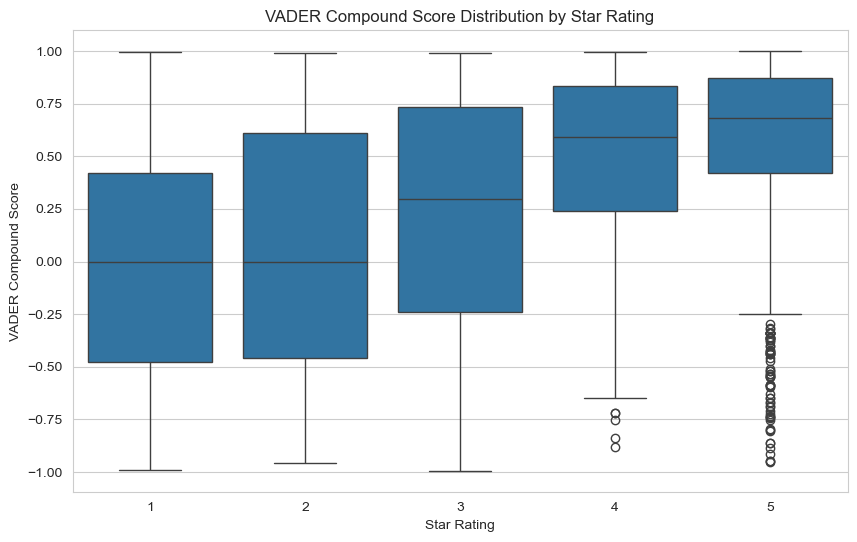

In [77]:
import logging
# Telling matplotlib to only show WARNINGs or higher, hiding INFO messages
logging.getLogger('matplotlib.category').setLevel(logging.WARNING)

plt.figure(figsize=(10, 6))
sns.boxplot(x='rating', y='compound_score', data=df)
plt.title('VADER Compound Score Distribution by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('VADER Compound Score')
plt.show()

**We see the upward trend, which is good. Now, I want to investigate the high number of outliers for 5 star ratings.**

In [78]:
# Finding 5-star reviews marked as 'Negative'
mismatched_positive = df[(df['rating'] == 5) & (df['sentiment_category'] == 'Negative')]
print("Highly-rated reviews classified as Negative:")
display(mismatched_positive[['rating', 'review', 'compound_score']].head())

# Finding 1-star reviews marked as 'Positive'
mismatched_negative = df[(df['rating'] == 1) & (df['sentiment_category'] == 'Positive')]
print("Poorly-rated reviews classified as Positive:")
display(mismatched_negative[['rating', 'review', 'compound_score']].head())

Highly-rated reviews classified as Negative:


,rating,review,compound_score
16,5,Headspace not only helps you meditate it has g...,-0.8002
135,5,An incredible journey into meditation. Supper ...,-0.0516
149,5,I’ve used headspace on and off for years to ma...,-0.8641
173,5,However… it doesnt play well with the 26 os an...,-0.4310
257,5,"I have a sleep disorder, with an inconvenient ...",-0.3626


Poorly-rated reviews classified as Positive:


,rating,review,compound_score
3,1,I’ve subscribed to Headspace for years and yea...,0.3730
5,1,I used to love headspace. I open the app and i...,0.6502
7,1,App said 14 day free trial. I clicked to join ...,0.9015
8,1,You will be charged for Annual fee when you si...,0.0624
12,1,I hate when app companies do this. I’m sure we...,0.9563


**These reviews help explain some things.**

**Why are Highly-rated reviews classified as Negative? Some of the reviews highlighted discuss difficult times that the app is helping with, but the difficult times would be classified as having negative sentiment. One has given it five stars but also mentions recent bugs.**

**Why are Poorly-rated reviews classified as Positive? Some of these highlighted reviews contain sarcasm and polite frustration, which can be misunderstood as positive sentiment. Additionally, there is use of past tense describing the app in a good light before switching to the negative review; the past tense part of the review has more "good" words that won out in its score.**

**I am assuming the majority of these incorrectly (likely, because it could be user error) rated reviews are nuanced and/or edited reviews. This is a limitation of VADER.**


# Comparing Sentiment Scores

**I want to compare sentiment scores between Calm and Headspace.**

In [79]:
# Calculating the average sentiment score for each app
df = pd.read_csv("Multi_Month_Reviews_with_Sentiment.csv")

# Full statistical summary of compound scores for each app
sentiment_summary = df.groupby('app_name')['compound_score'].describe()

print("Sentiment Score Summary by App")
display(sentiment_summary)

Sentiment Score Summary by App


,count,mean,std,min,25%,50%,75%,max
app_name,,,,,,,,
Calm,3002.0,0.333713,0.524952,-0.9963,0.0000,0.48845,0.7868,0.9983
Headspace,2562.0,0.107066,0.582569,-0.9889,-0.4019,0.07720,0.6590,0.9960


**Calm clearly outperforms Headspace in overall user sentiment. The fact that Calm's 25th percentile rests at absolute zero is a great highlight. It means that 75% of all Calm reviews are completely neutral or positive (score ≥ 0). Only the bottom 25% of Calm's reviews drop below a neutral sentiment. It perfectly illustrates how much rarer negative sentiment is for Calm compared to Headspace.**

**In stark contrast, Headspace's 25th percentile is -0.40. This means that the bottom 25% of Headspace reviews are solidly negative, showing a much larger proportion of highly critical reviews compared to Calm.**

**Calm has a noticeably higher *average* sentiment score (0.33) compared to Headspace (0.11).
The *midpoint* of Calm's reviews is 0.49 (quite positive), whereas Headspace's median is much closer to neutral at 0.08. This further confirms that the typical Calm review is substantially more positive than the typical Headspace review.**

**Headspace has a slightly higher standard deviation (0.58) than Calm (0.52). Because Headspace's median is so much lower, this higher *SD* suggests that Headspace's reviews are more polarized. This means users are more split between loving the app and being highly frustrated by it, whereas Calm users generally lean more uniformly toward the positive side.**

In [80]:
# Checking the breakdown by App Store / Platform
print("Review counts by Platform:")
print(df['source'].value_counts())

Review counts by Platform:
source
Google Play        3682
Apple App Store    1882
Name: count, dtype: int64


In [81]:
# Comparing the distribution of the 'Positive', 'Neutral', and 'Negative' categories
# Getting the percentage distribution of sentiment categories for each app
category_distribution = df.groupby('app_name')['sentiment_category'].value_counts(normalize=True).mul(100).rename('percent').reset_index()

print("Sentiment Category Distribution by App")
display(category_distribution.pivot_table(index='app_name', columns='sentiment_category', values='percent'))

Sentiment Category Distribution by App


sentiment_category,Negative,Neutral,Positive
app_name,,,
Calm,21.119254,13.191206,65.689540
Headspace,39.032006,10.265418,50.702576


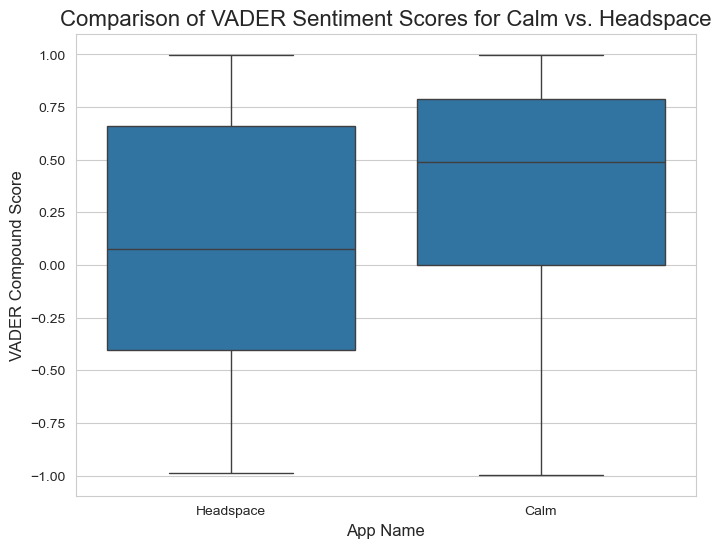

In [82]:
# Visualizations
sns.set_style("whitegrid")

# Boxplot to compare the distribution of compound scores
plt.figure(figsize=(8, 6))
sns.boxplot(x='app_name', y='compound_score', data=df)
plt.title('Comparison of VADER Sentiment Scores for Calm vs. Headspace', fontsize=16)
plt.xlabel('App Name', fontsize=12)
plt.ylabel('VADER Compound Score', fontsize=12)
plt.show()

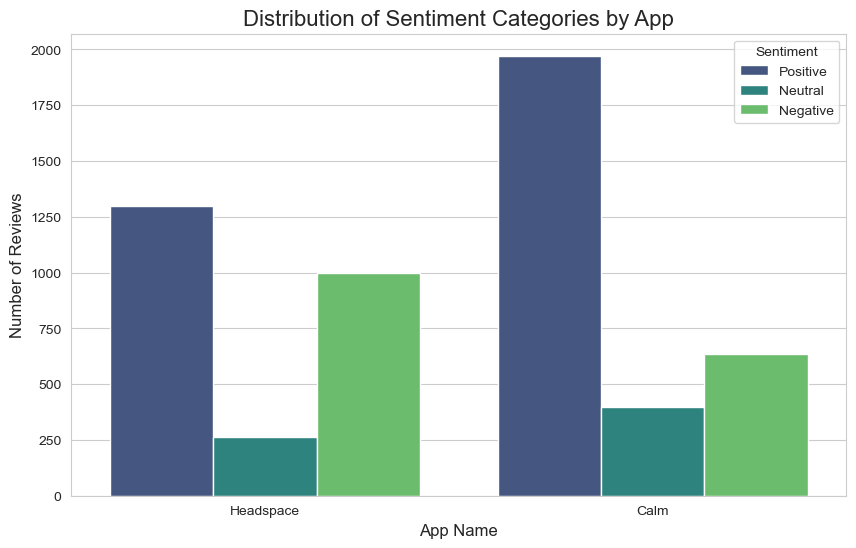

In [83]:
# A grouped bar chart to compare sentiment categories
plt.figure(figsize=(10, 6))
sns.countplot(x='app_name', hue='sentiment_category', data=df, palette='viridis', hue_order=['Positive', 'Neutral', 'Negative'])
plt.title('Distribution of Sentiment Categories by App', fontsize=16)
plt.xlabel('App Name', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.legend(title='Sentiment')
plt.show()

**Comparing percentages and seeing these visualizations further confirms that Calm outperforms Headspace**

**To confirm that these observed differences were not due to random chance, Welch's *t*-test and a chi-square test will be conducted.**

# Statistical Analysis Continues

**Is the average sentiment score for Calm reviews *significantly* higher than the average score for Headspace reviews?**

In [84]:
from scipy.stats import ttest_ind

# 1. Isolating the compound scores for each app
calm_scores = df[df['app_name'] == 'Calm']['compound_score']
headspace_scores = df[df['app_name'] == 'Headspace']['compound_score']

# 2. Independent samples t-test
# Performing Welch's t-test, which doesn't assume equal variance and is a safer default
t_stat, p_value = ttest_ind(calm_scores, headspace_scores, equal_var=False)

print(f"t-test results: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

# 3. Interpreting the result
if p_value < 0.05:
    print("The p-value is less than 0.05, so we can conclude that there is a statistically significant difference in the mean sentiment scores between Calm and Headspace.")
else:
    print("The p-value is not less than 0.05, so we cannot conclude that there is a statistically significant difference in the mean sentiment scores.")


t-test results: t-statistic = 15.1345, p-value = 0.0000
The p-value is less than 0.05, so we can conclude that there is a statistically significant difference in the mean sentiment scores between Calm and Headspace.


**This test compared the mean compound_score of Calm and Headspace. The result was a *t*-statistic of 15.13 and a *p*-value of 0.0000. Since the *p*-value is far below the standard threshold of 0.05, we can conclude that the higher mean sentiment score for Calm is statistically significant.**

**Is the proportion of Positive, Neutral, and Negative reviews *significantly* different between Calm and Headspace?**

In [85]:
from scipy.stats import chi2_contingency

# 1. Contingency table
contingency_table = pd.crosstab(df['app_name'], df['sentiment_category'])

print("Contingency Table")
display(contingency_table)

# 2. Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square test results: Chi2 statistic = {chi2:.4f}, P-value = {p_value:.4f}")

# 3. Interpreting the result
if p_value < 0.05:
    print("The p-value is less than 0.05, indicating a significant association between the app and the sentiment category.")
    print("This means the distribution of positive/negative/neutral reviews is different for Calm and Headspace.")
else:
    print("The p-value is not less than 0.05, so we cannot conclude there is a significant association between the app and the sentiment category.")

Contingency Table


sentiment_category,Negative,Neutral,Positive
app_name,,,
Calm,634,396,1972
Headspace,1000,263,1299


Chi-Square test results: Chi2 statistic = 213.8328, P-value = 0.0000
The p-value is less than 0.05, indicating a significant association between the app and the sentiment category.
This means the distribution of positive/negative/neutral reviews is different for Calm and Headspace.


**This test assessed whether there was a significant association between the app and the distribution of sentiment categories (Positive, Neutral, Negative). The test yielded a chi-square statistic of 213.83 and a *p*-value of 0.0000. This confirms a significant relationship, meaning the different proportions of positive and negative reviews for each app are statistically significant.**

# Statistical Analysis of VADER Overall

**The statistical analysis provides robust and multifaceted evidence that users express significantly more positive sentiment towards Calm than Headspace. This is confirmed by Calm’s higher average sentiment score, its drastically smaller and less severe base of negative reviews, and its higher proportion of positive-rated reviews, with all findings being statistically significant.**

In [7]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.8 MB/s eta 0:00:00


# Error/Change

**Had to move to Google Colab, because I just didn't have enough memory on my computer, but copied over once it was run through.**

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Reviews_with_Sentiment.csv to Reviews_with_Sentiment.csv


Completed in Google Colab

# Topic Modeling: BERTopic

## RQ2: What specific features or aspects of the apps are the primary drivers of positive and negative user sentiment?
We begin to address RQ2 before turning to sentiment analysis.

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [2]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 2.1 MB/s eta 0:00:00


In [34]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk

# Ensuring NLTK data is downloaded
nltk.download('stopwords')

#  Step 1: Loading and Filtering Data
df = pd.read_csv('Reviews_with_Sentiment.csv')
df_headspace_neg = df[(df['app_name'] == 'Headspace') & (df['sentiment_category'] == 'Negative')].copy()

print(f"Found {len(df_headspace_neg)} negative reviews for 'Headspace'.")

#  Step 2: Running Topic Modeling to Generate Topics
df_headspace_neg.dropna(subset=['cleaned_review'], inplace=True)
has_text = df_headspace_neg['cleaned_review'].astype(str).str.strip() != ''
df_headspace_neg = df_headspace_neg[has_text]

print(f"Documents remaining for modeling after cleaning: {len(df_headspace_neg)}")

if len(df_headspace_neg) > 0:
    docs_neg = df_headspace_neg['cleaned_review'].tolist()

    stop_words = list(stopwords.words('english'))
    stop_words.extend(['headspace', 'app', 'calm', 'meditation', 'use', 'get', 'really'])
    vectorizer_model = CountVectorizer(stop_words=stop_words)

    topic_model_neg = BERTopic(
        vectorizer_model=vectorizer_model,
        language="english",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=11 # This will generate topics -1 through 9
    )

    topics, _ = topic_model_neg.fit_transform(docs_neg)
    df_headspace_neg['dominant_topic'] = topics
    print("Successfully ran topic modeling!")

    #  Step 3: Mapping Topic Numbers to Readable Names

    # ***FIX***: BERTopic numbers are -1, 0, 1... so the map's keys should match.
    topic_name_map_headspace_neg = {
        -1: "Outliers & Miscellaneous", # It's good practice to label the outlier topic
        0: "Critical Bugs & Failures",
        1: "Cancellation & Billing Disputes",
        2: "Frustrating UI & Crashes",
        3: "Subscription & Refund Issues",
        4: "Perceived Value for Money",
        5: "Usability Issues (Lock Screen)",
        6: "Specific Feature Bugs (Sleep)",
        7: "Content & Feature Complaints",
        8: "Annoying Changes & Monetization",
        9: "Aggressive Billing & Trials"
    }

    # ***FIX***: Map directly to the topic number. No need to add 1.
    df_headspace_neg['topic_name'] = df_headspace_neg['dominant_topic'].map(topic_name_map_headspace_neg)
    print("Successfully mapped topic names!")
    print(df_headspace_neg[['dominant_topic', 'topic_name']].head())

    print(" Topic Name Counts ")
    print(df_headspace_neg['topic_name'].value_counts(dropna=False))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2025-12-12 22:15:07,107 - BERTopic - Embedding - Transforming documents to embeddings.


Found 656 negative reviews for 'Headspace'.
Documents remaining for modeling after cleaning: 656


Batches:   0%|          | 0/21 [00:00<?, ?it/s]

2025-12-12 22:15:34,003 - BERTopic - Embedding - Completed ✓
2025-12-12 22:15:34,004 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-12 22:15:35,588 - BERTopic - Dimensionality - Completed ✓
2025-12-12 22:15:35,590 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-12 22:15:35,637 - BERTopic - Cluster - Completed ✓
2025-12-12 22:15:35,638 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-12 22:15:35,698 - BERTopic - Representation - Completed ✓
2025-12-12 22:15:35,699 - BERTopic - Topic reduction - Reducing number of topics
2025-12-12 22:15:35,700 - BERTopic - Topic reduction - Number of topics (11) is equal or higher than the clustered topics(9).
2025-12-12 22:15:35,703 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-12 22:15:35,964 - BERTopic - Representation - Completed ✓



Successfully ran topic modeling!
Successfully mapped topic names!
   dominant_topic                     topic_name
0               6  Specific Feature Bugs (Sleep)
1               6  Specific Feature Bugs (Sleep)
2               2       Frustrating UI & Crashes
3               2       Frustrating UI & Crashes
4               2       Frustrating UI & Crashes

--- Topic Name Counts ---
topic_name
Frustrating UI & Crashes           331
Cancellation & Billing Disputes    104
Outliers & Miscellaneous            72
Content & Feature Complaints        50
Specific Feature Bugs (Sleep)       44
Usability Issues (Lock Screen)      21
Critical Bugs & Failures            12
Subscription & Refund Issues        11
Perceived Value for Money           11
Name: count, dtype: int64


In [12]:
# Isolating corpora to begin the process of Topic Modeling
import emoji
from nltk.tokenize import word_tokenize
import pandas as pd
import re

# Loading data with sentiment scores
df = pd.read_csv("Reviews_with_Sentiment.csv")
# Ensuring the 'review' column is treated as a string, handling potential empty reviews
df['review'] = df['review'].astype(str).fillna('')

# Final text preprocessing function
def preprocess_text_final_with_numbers(text):
    """Cleans text for topic modeling, preserving numbers."""
    if not isinstance(text, str):
        return ""
    text = emoji.demojize(text).lower()
    contractions_dict = { "it's": "it is", "don't": "do not", "can't": "cannot", "i'm": "i am", "you're": "you are", "we're": "we are", "they're": "they are", "isn't": "is not", "wasn't": "was not", "aren't": "are not", "weren't": "were not", "haven't": "have not", "hasn't": "has not", "hadn't": "had not", "won't": "will not", "wouldn't": "would not", "shouldn't": "should not", "couldn't": "could not", "i've": "i have", "you've": "you have"}
    for contraction, expansion in contractions_dict.items():
        text = text.replace(contraction, expansion)
    text = re.sub(r'[^a-z0-9\s_:]', '', text)
    tokens = word_tokenize(text)
    minimal_stop_words = {'a', 'an', 'the', 'and', 'in', 'on', 'to'}
    cleaned_tokens = [word for word in tokens if word not in minimal_stop_words]
    return " ".join(cleaned_tokens)

**I have to keep importing nltk and the like because I find errors in the dataset and restart; I find something errors out and I need to restart the kernel; or I come back a day later to continue analysis.**

In [19]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [20]:
# Isolating Corpora by Sentiment

#1: Filtering the dataframe
positive_reviews_df = df[df['sentiment_category'] == 'Positive'].copy()
negative_reviews_df = df[df['sentiment_category'] == 'Negative'].copy()

# 2 & 3: Preprocessing the text and creating the final list (corpus)
positive_corpus = positive_reviews_df['review'].apply(preprocess_text_final_with_numbers).tolist()

negative_corpus = negative_reviews_df['review'].apply(preprocess_text_final_with_numbers).tolist()

print(f"Created a corpus of {len(positive_corpus)} positive reviews.")
print(f"Created a corpus of {len(negative_corpus)} negative reviews.")

Created a corpus of 2513 positive reviews.
Created a corpus of 1037 negative reviews.


In [21]:
# Isolating Corpora by App AND Sentiment

# Filtering for each of the four groups
calm_positive_df = df[(df['app_name'] == 'Calm') & (df['sentiment_category'] == 'Positive')].copy()
calm_negative_df = df[(df['app_name'] == 'Calm') & (df['sentiment_category'] == 'Negative')].copy()

headspace_positive_df = df[(df['app_name'] == 'Headspace') & (df['sentiment_category'] == 'Positive')].copy()
headspace_negative_df = df[(df['app_name'] == 'Headspace') & (df['sentiment_category'] == 'Negative')].copy()

# Preprocessing and creating the four corpora
calm_positive_corpus = calm_positive_df['review'].apply(preprocess_text_final_with_numbers).tolist()

calm_negative_corpus = calm_negative_df['review'].apply(preprocess_text_final_with_numbers).tolist()

headspace_positive_corpus = headspace_positive_df['review'].apply(preprocess_text_final_with_numbers).tolist()

headspace_negative_corpus = headspace_negative_df['review'].apply(preprocess_text_final_with_numbers).tolist()


print(f"Calm: {len(calm_positive_corpus)} positive reviews, {len(calm_negative_corpus)} negative reviews.")
print(f"Headspace: {len(headspace_positive_corpus)} positive reviews, {len(headspace_negative_corpus)} negative reviews.")

Calm: 1357 positive reviews, 381 negative reviews.
Headspace: 1156 positive reviews, 656 negative reviews.


**Sentiment analysis revealed a predominantly positive user base, with 1,818 positive reviews compared to 815 negative reviews. To understand the drivers behind these sentiments, I will conduct separate topic modeling analyses on each group.**

**These numbers changed several times as I had to re-run the data.***

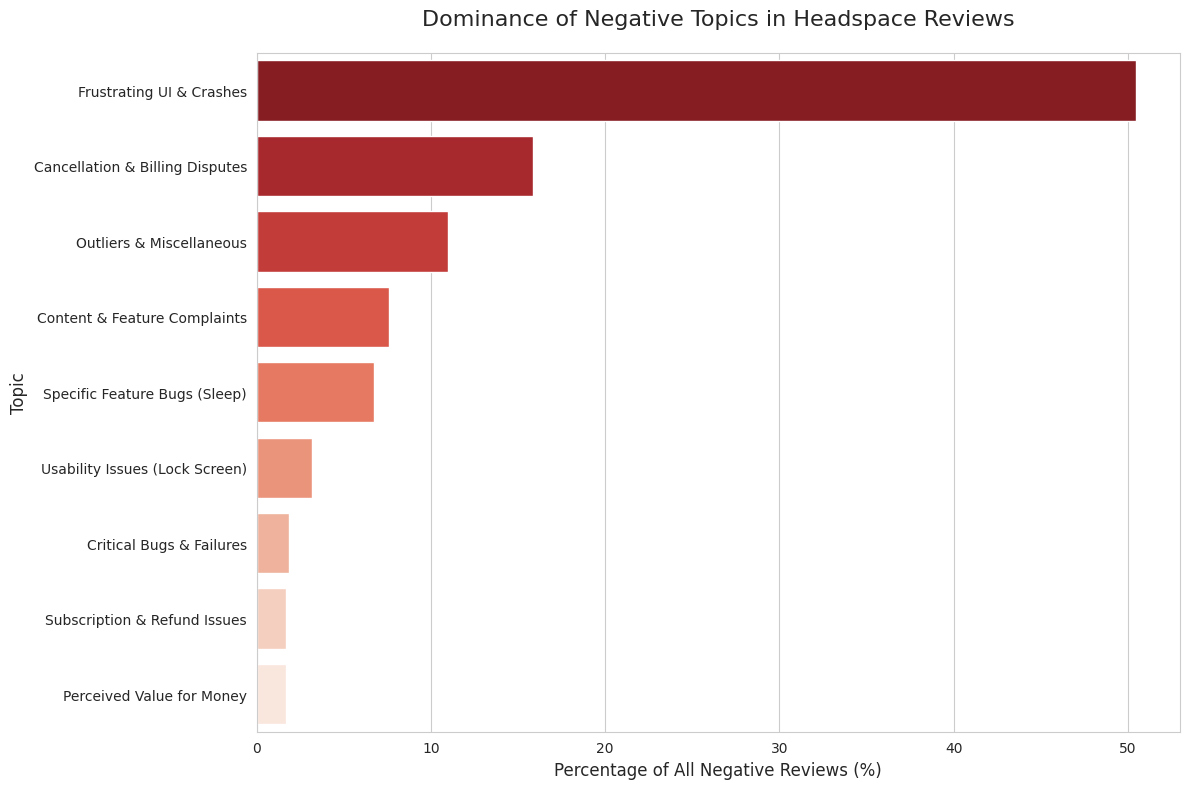

In [76]:
# Step 4: Creating the Visualization
sns.set_style("whitegrid")
topic_counts = df_headspace_neg['topic_name'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 8))
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Reds_r')

plt.title("Dominance of Negative Topics in Headspace Reviews", fontsize=16, pad=20)
plt.xlabel("Percentage of All Negative Reviews (%)", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**This chart reveals that Headspace's negative reviews are overwhelmingly driven by technical issues, with a full 50% of all complaints stemming from a frustrating UI and app crashes. The second-largest source of dissatisfaction comes from billing and cancellation disputes, indicating that the app's fundamental performance and its business model are the primary sources of user frustration, rather than its meditation and mindfulness content.**

In [57]:
#  Step 1: Loading and Filtering My Data
df = pd.read_csv('Reviews_with_Sentiment.csv')

# ***FIX: Changed df_headspace_neg to df_headspace_pos to store the positive reviews correctly.
df_headspace_pos = df[(df['app_name'] == 'Headspace') & (df['sentiment_category'] == 'Positive')].copy()

# ***FIX: This print statement now correctly refers to the DataFrame created above.
print(f"Found {len(df_headspace_pos)} positive reviews for 'Headspace'.")


#  Step 2: Running Topic Modeling to Generate Topics

# All subsequent lines now correctly operate on df_headspace_pos
df_headspace_pos.dropna(subset=['cleaned_review'], inplace=True)
has_text = df_headspace_pos['cleaned_review'].astype(str).str.strip() != ''
df_headspace_pos = df_headspace_pos[has_text]

print(f"Documents remaining for modeling after cleaning: {len(df_headspace_pos)}")

if len(df_headspace_pos) > 0:
    # Use 'docs_pos' for clarity
    docs_pos = df_headspace_pos['cleaned_review'].tolist()

    stop_words = list(stopwords.words('english'))
    stop_words.extend(['headspace', 'app', 'calm', 'meditation', 'use', 'get', 'really', 'like', 'love', 'great'])
    vectorizer_model = CountVectorizer(stop_words=stop_words)

    # ***FIX: Renamed model to topic_model_pos for consistency
    topic_model_pos = BERTopic(
        vectorizer_model=vectorizer_model,
        language="english",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=10 # This will generate topics -1 through 8
    )

    # Fitting the model and get topics
    topics, _ = topic_model_pos.fit_transform(docs_pos)
    df_headspace_pos['dominant_topic'] = topics
    print("Successfully ran topic modeling!")


    #  Step 3: Mapping Topic Numbers to Readable Names

    # Corrected map
    topic_name_map_pos = {
        -1: "Outliers & Miscellaneous",
        0: "Anxiety, Stress & Mood",
        1: "Sleep Quality & Sleepcasts",
        2: "Guided Meditation & Andy's Voice",
        3: "Life-Changing & Daily Routine",
        4: "Content Variety (Music, Focus)",
        5: "Beginner-Friendly & Easy to Use",
        6: "Pain & Health Management",
        7: "AI Support & New Features",
        8: "Customer Service & Account Issues"
    }

    # ***FIX: Map to df_headspace_pos, not a non-existent '_sample' DataFrame
    df_headspace_pos['topic_name'] = df_headspace_pos['dominant_topic'].map(topic_name_map_pos)

    print("Successfully mapped topic names for positive reviews!")

    # Displaying the final results to verify
    display(df_headspace_pos[['cleaned_review', 'dominant_topic', 'topic_name']].head())

else:
    print("Warning: No documents found after filtering. Topic modeling was skipped.")

2025-12-12 21:41:34,637 - BERTopic - Embedding - Transforming documents to embeddings.


Found 1156 positive reviews for 'Headspace'.
Documents remaining for modeling after cleaning: 1156


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

2025-12-12 21:42:19,422 - BERTopic - Embedding - Completed ✓
2025-12-12 21:42:19,424 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-12 21:42:24,141 - BERTopic - Dimensionality - Completed ✓
2025-12-12 21:42:24,142 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-12 21:42:24,243 - BERTopic - Cluster - Completed ✓
2025-12-12 21:42:24,244 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-12 21:42:24,332 - BERTopic - Representation - Completed ✓
2025-12-12 21:42:24,333 - BERTopic - Topic reduction - Reducing number of topics
2025-12-12 21:42:24,351 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-12 21:42:24,429 - BERTopic - Representation - Completed ✓
2025-12-12 21:42:24,432 - BERTopic - Topic reduction - Reduced number of topics from 22 to 10



Successfully ran topic modeling!

Successfully mapped topic names for positive reviews!


,cleaned_review,dominant_topic,topic_name
5,I'm having the same issue as a lot of people a...,1,Sleep Quality & Sleepcasts
6,The app was great until the update. Now it tak...,1,Sleep Quality & Sleepcasts
8,I used to love this app but for the past month...,-1,Outliers & Miscellaneous
11,I've enjoyed using the app over the years but ...,0,"Anxiety, Stress & Mood"
25,"I love the content, but this must be the least...",1,Sleep Quality & Sleepcasts


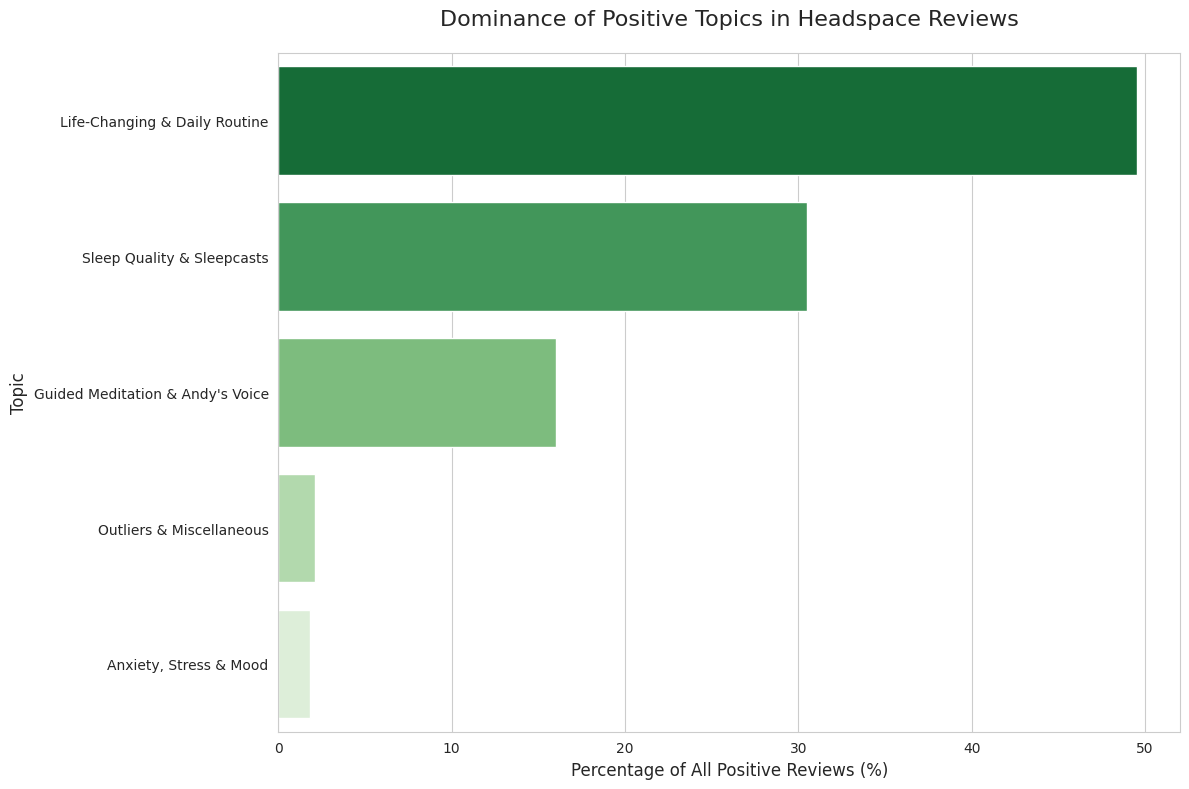

In [58]:
# Step 4: Creating the Visualization

# Setting the visual style for the plot
sns.set_style("whitegrid")

# Calculating the percentage of each topic
# Excluding the outlier topic (-1) by filtering for non-null topic names.
topic_counts = df_headspace_pos_sample['topic_name'].value_counts(normalize=True).dropna() * 100

# Creating the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Greens_r', saturation=0.8)

# Adding titles and labels for clarity
plt.title("Dominance of Positive Topics in Headspace Reviews", fontsize=16, pad=20)
plt.xlabel("Percentage of All Positive Reviews (%)", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Ensuring a clean layout and display the plot
plt.tight_layout()
plt.show()

**This chart suggests that Headspace's success is overwhelmingly driven by its ability to integrate into users' lives as a transformative daily habit, a theme that accounts for nearly half of all positive reviews. The second most-praised feature is its effectiveness in improving sleep, indicating that users value the tangible, routine-based outcomes far more than any other aspect of the app.**

In [59]:
# Ensuring NLTK data is downloaded
nltk.download('stopwords')

# Step 1: Loading and Filtering Data for Calm
df = pd.read_csv('Reviews_with_Sentiment.csv')

# ***FIX***: Using .str.lower() to make the filter case-insensitive (catches 'Calm' and 'calm')
df_calm_neg = df[(df['app_name'].str.lower() == 'calm') & (df['sentiment_category'] == 'Negative')].copy()

print(f"Found {len(df_calm_neg)} negative reviews for 'Calm'.")


# Step 2: Running Topic Modeling (if data exists)
if len(df_calm_neg) > 0:
    # Cleaning the 'cleaned_review' column
    df_calm_neg.dropna(subset=['cleaned_review'], inplace=True)
    has_text = df_calm_neg['cleaned_review'].astype(str).str.strip() != ''
    df_calm_neg = df_calm_neg[has_text]

    print(f"Documents remaining for modeling after cleaning: {len(df_calm_neg)}")
    docs_calm_neg = df_calm_neg['cleaned_review'].tolist()

    # Defining stop words
    stop_words = list(stopwords.words('english'))
    stop_words.extend(['calm', 'app', 'headspace', 'meditation', 'use', 'get', 'really', 'even'])
    vectorizer_model = CountVectorizer(stop_words=stop_words)

    # Initializing and running BERTopic model
    topic_model_calm_neg = BERTopic(
        vectorizer_model=vectorizer_model,
        language="english",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=11 # Request 11 to get topics -1 through 9
    )

    topics, _ = topic_model_calm_neg.fit_transform(docs_calm_neg)
    df_calm_neg['dominant_topic'] = topics
    print("Successfully ran topic modeling!")


    # Step 3: Mapping Topic Numbers to Readable Names (Corrected)

    # ***FIX***: The map's keys now match BERTopic's output (-1, 0, 1, ...).
    topic_name_map_calm_neg = {
        -1: "Outliers & Miscellaneous",
        0: "Subscription & Cancellation Traps",
        1: "App Stability & Crash Reports",
        2: "Audio Playback & Download Failures",
        3: "Aggressive Upselling & Dark Patterns",
        4: "Poor Customer Support Experience",
        5: "Misleading 'Free' Content & Paywalls",
        6: "Navigation & UI Complexity",
        7: "Sleep Story & Music Bugs",
        8: "Account Sync & Login Problems",
        9: "Missing or Removed Features"
    }

    # ***FIX***: Map directly to the topic number. No need to add 1.
    df_calm_neg['topic_name'] = df_calm_neg['dominant_topic'].map(topic_name_map_calm_neg)

    print("Successfully mapped topic names for Calm's negative reviews!")

    # Displaying the final results to verify
    display(df_calm_neg[['cleaned_review', 'dominant_topic', 'topic_name']].head())

else:
    print("Warning: No negative reviews found for 'Calm'. Topic modeling was skipped.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2025-12-12 21:46:02,019 - BERTopic - Embedding - Transforming documents to embeddings.


Found 381 negative reviews for 'Calm'.
Documents remaining for modeling after cleaning: 381


Batches:   0%|          | 0/12 [00:00<?, ?it/s]

2025-12-12 21:46:15,251 - BERTopic - Embedding - Completed ✓
2025-12-12 21:46:15,254 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-12 21:46:16,030 - BERTopic - Dimensionality - Completed ✓
2025-12-12 21:46:16,031 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-12 21:46:16,060 - BERTopic - Cluster - Completed ✓
2025-12-12 21:46:16,061 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-12 21:46:16,088 - BERTopic - Representation - Completed ✓
2025-12-12 21:46:16,089 - BERTopic - Topic reduction - Reducing number of topics
2025-12-12 21:46:16,090 - BERTopic - Topic reduction - Number of topics (11) is equal or higher than the clustered topics(4).
2025-12-12 21:46:16,092 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-12 21:46:16,224 - BERTopic - Representation - Completed ✓



Successfully ran topic modeling!

Successfully mapped topic names for Calm's negative reviews!


,cleaned_review,dominant_topic,topic_name
1010,Stressing me out this is not helpful at all,2,Audio Playback & Download Failures
1019,I loved this app… until one day I just was una...,2,Audio Playback & Download Failures
1026,I’ll change my review when support actually an...,2,Audio Playback & Download Failures
1027,There is a very steep penalty for forgetting t...,2,Audio Playback & Download Failures
1030,I signed up for the paid content. I had been a...,2,Audio Playback & Download Failures


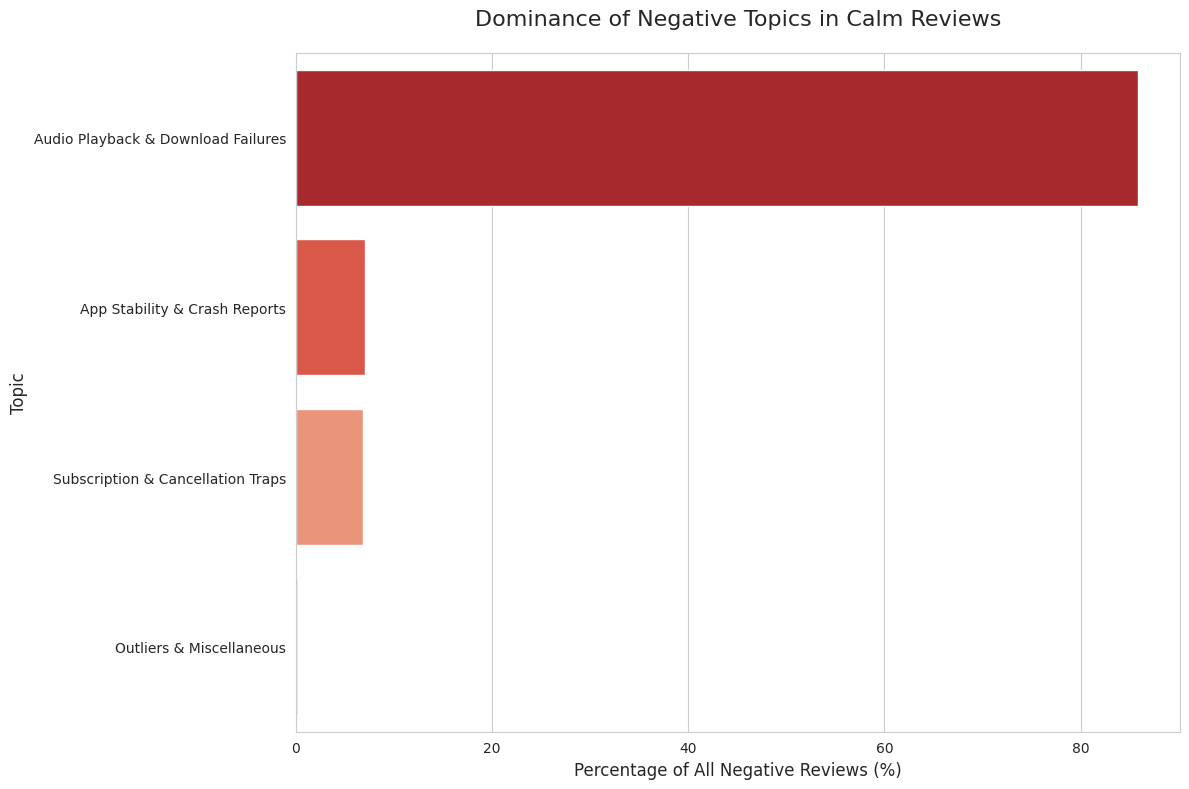

In [60]:
# Step 4: Creating a Visualization

# Setting the visual style
sns.set_style("whitegrid")

# Calculating the percentage of each topic, ignoring outliers (where topic_name is NaN)
topic_counts = df_calm_neg['topic_name'].value_counts(normalize=True).dropna() * 100

# Creating the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Reds_r')

# Adding titles and labels for clarity
plt.title("Dominance of Negative Topics in Calm Reviews", fontsize=16, pad=20)
plt.xlabel("Percentage of All Negative Reviews (%)", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Displaying the final plot
plt.tight_layout()
plt.show()

**Based on the chart, negative reviews for the Calm app are overwhelmingly dominated by a single category: "Audio Playback & Download Failures." This single topic accounts for nearly 90% of all negative feedback analyzed. Other issues, such as app stability and subscription problems, represent a much smaller fraction of user complaints.**

In [61]:
# Step 1: Loading and Filtering Data for Calm Positive Reviews
df = pd.read_csv('Reviews_with_Sentiment.csv')

# ***FIX***: Using .str.lower() to make the filter case-insensitive.
df_calm_pos = df[(df['app_name'].str.lower() == 'calm') & (df['sentiment_category'] == 'Positive')].copy()

print(f"Found {len(df_calm_pos)} positive reviews for 'Calm'.")


# Step 2: Running Topic Modeling (if data exists)
if len(df_calm_pos) > 0:
    # Cleaning the 'cleaned_review' column
    df_calm_pos.dropna(subset=['cleaned_review'], inplace=True)
    has_text = df_calm_pos['cleaned_review'].astype(str).str.strip() != ''
    df_calm_pos = df_calm_pos[has_text]

    print(f"Documents remaining for modeling after cleaning: {len(df_calm_pos)}")
    docs_calm_pos = df_calm_pos['cleaned_review'].tolist()

    # Defining stop words
    stop_words = list(stopwords.words('english'))
    stop_words.extend(['calm', 'app', 'headspace', 'meditation', 'use', 'get', 'really', 'even', 'love', 'great', 'like'])
    vectorizer_model = CountVectorizer(stop_words=stop_words)

    # Initializing and running BERTopic model
    topic_model_calm_pos = BERTopic(
        vectorizer_model=vectorizer_model,
        language="english",
        calculate_probabilities=True,
        verbose=True,
        nr_topics=9 # Requesting 9 to get topics -1 through 7
    )

    topics, _ = topic_model_calm_pos.fit_transform(docs_calm_pos)
    df_calm_pos['dominant_topic'] = topics
    print("Successfully ran topic modeling!")


    # Step 3: Mapping Topic Numbers to Readable Names (Corrected)

    # ***FIX***: The map's keys now match BERTopic's output (-1, 0, 1, ...).
    topic_name_map_calm_pos = {
        -1: "Outliers & Miscellaneous",
        0: "Sleep Stories & Soundscapes",
        1: "Anxiety & Stress Reduction",
        2: "Guided Meditations & Daily Calm",
        3: "Life-Changing & Daily Habit",
        4: "Content Variety (Music, Masterclass)",
        5: "Beginner-Friendly & Easy Interface",
        6: "Narrator Voices (Tamara Levitt)",
        7: "Focus & Productivity"
    }

    # ***FIX***: Map directly to the topic number. No need to add 1.
    df_calm_pos['topic_name'] = df_calm_pos['dominant_topic'].map(topic_name_map_calm_pos)

    print("Successfully mapped topic names for Calm's positive reviews!")

    # Displaying the final results to verify
    display(df_calm_pos[['cleaned_review', 'dominant_topic', 'topic_name']].head())

else:
    print("Warning: No positive reviews found for 'Calm'. Topic modeling was skipped.")

2025-12-12 21:48:19,192 - BERTopic - Embedding - Transforming documents to embeddings.


Found 1357 positive reviews for 'Calm'.
Documents remaining for modeling after cleaning: 1357


Batches:   0%|          | 0/43 [00:00<?, ?it/s]

2025-12-12 21:48:52,784 - BERTopic - Embedding - Completed ✓
2025-12-12 21:48:52,786 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-12 21:48:58,417 - BERTopic - Dimensionality - Completed ✓
2025-12-12 21:48:58,418 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-12 21:48:58,550 - BERTopic - Cluster - Completed ✓
2025-12-12 21:48:58,552 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-12 21:48:58,629 - BERTopic - Representation - Completed ✓
2025-12-12 21:48:58,630 - BERTopic - Topic reduction - Reducing number of topics
2025-12-12 21:48:58,639 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-12 21:48:58,698 - BERTopic - Representation - Completed ✓
2025-12-12 21:48:58,701 - BERTopic - Topic reduction - Reduced number of topics from 22 to 9



Successfully ran topic modeling!

Successfully mapped topic names for Calm's positive reviews!


,cleaned_review,dominant_topic,topic_name
1000,I don’t like the yearly charge,1,Anxiety & Stress Reduction
1001,So calming and nice stories. I have been using...,4,"Content Variety (Music, Masterclass)"
1002,You must have to get the paid out because I do...,1,Anxiety & Stress Reduction
1003,Why do I need to make an account to listen to ...,1,Anxiety & Stress Reduction
1005,I used to be able to listen to some things for...,1,Anxiety & Stress Reduction


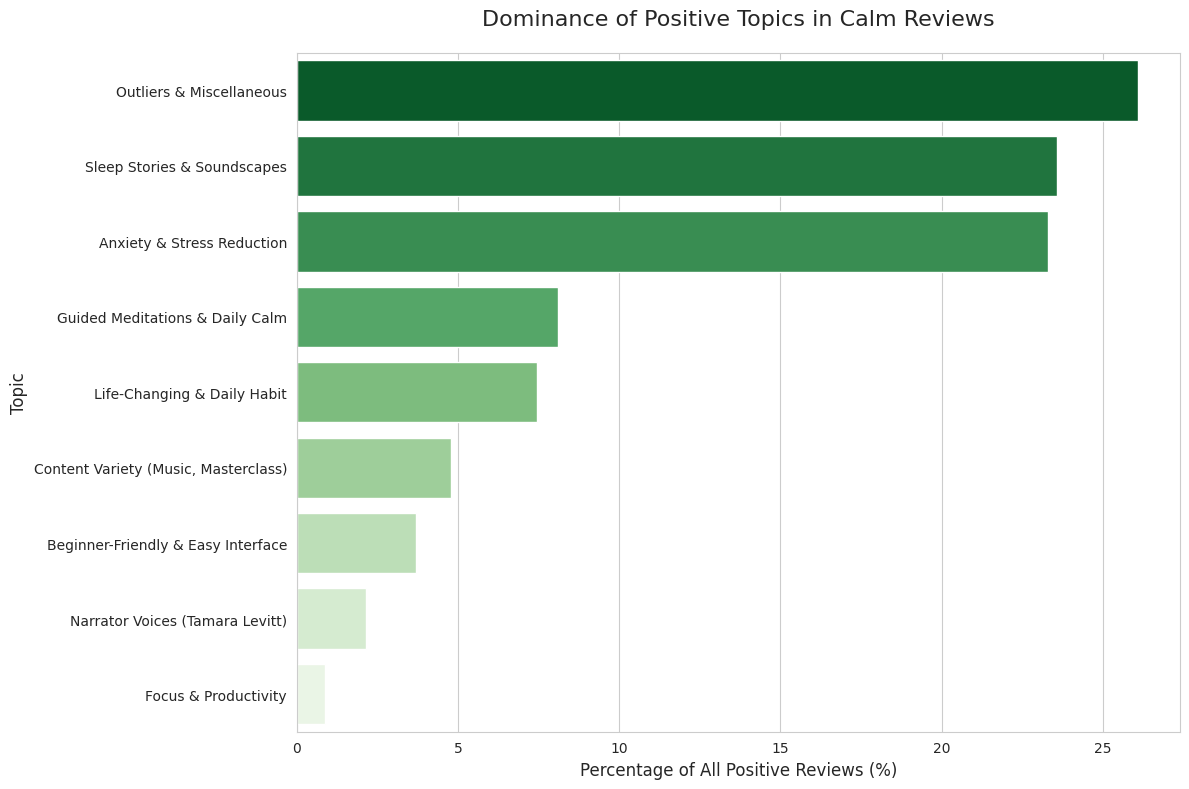

In [62]:
# Step 4: Creating the Visualization

# Setting the visual style for the plot
sns.set_style("whitegrid")

# Calculating the percentage of each topic, ignoring outliers
topic_counts = df_calm_pos['topic_name'].value_counts(normalize=True).dropna() * 100

# Creating the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=topic_counts.values, y=topic_counts.index, palette='Greens_r', saturation=0.8)

# Adding titles and labels for clarity
plt.title("Dominance of Positive Topics in Calm Reviews", fontsize=16, pad=20)
plt.xlabel("Percentage of All Positive Reviews (%)", fontsize=12)
plt.ylabel("Topic", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Displaying the final plot
plt.tight_layout()
plt.show()

**Positive reviews for the Calm app are overwhelmingly driven by its effectiveness in improving sleep and reducing anxiety, with "Sleep Stories & Soundscapes" and "Anxiety & Stress Reduction" standing out as the two most dominant themes. These two topics are praised almost equally and far more frequently than other features like guided meditations or the app's interface. This indicates that users value Calm primarily for its tangible benefits related to sleep and stress management.**

In [73]:
# having issues, pausing

print("1. DataFrame Info ")
# This shows column names, data types, and how many non-empty values exist.
# Looking for 'topic_name' to see if it has fewer non-null values than other columns.
all_analyzed_reviews.info()

print("2. DataFrame Head")
# This shows the first few rows. Seeing if 'app_name' and 'topic_name' look correct.
print(all_analyzed_reviews.head())

print("3. App Name Value Counts")
# This shows every unique 'app_name' and how many times it appears.
# This will reveal any spelling, case, or whitespace issues.
print(all_analyzed_reviews['app_name'].value_counts(dropna=False))

print("4. Topic Name Value Counts")
# This is the most critical one. It will list ALL topic names that exist
# in the dataframe and their counts. It will also show if there are any NaN (empty) values.
print(all_analyzed_reviews['topic_name'].value_counts(dropna=False))

--- 1. DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4050 entries, 5 to 3998
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   app_name            4050 non-null   object        
 1   source              4050 non-null   object        
 2   review              4050 non-null   object        
 3   rating              4050 non-null   int64         
 4   date                1855 non-null   datetime64[ns]
 5   cleaned_review      4050 non-null   object        
 6   sentiment_scores    4050 non-null   object        
 7   compound_score      4050 non-null   float64       
 8   positive_score      4050 non-null   float64       
 9   neutral_score       4050 non-null   float64       
 10  negative_score      4050 non-null   float64       
 11  sentiment_category  4050 non-null   object        
 12  dominant_topic      2894 non-null   float64       
 13  topic_name          2894 no

Analyzing Trends Over Time

In [78]:
# Re-running this cell!
all_analyzed_reviews = pd.concat([
    df_headspace_pos,
    df_headspace_neg,
    df_calm_pos,
    df_calm_neg
])
all_analyzed_reviews['date'] = pd.to_datetime(all_analyzed_reviews['date'])

Attempting to find reviews for App: 'Headspace' and Topic: 'Frustrating UI & Crashes'...

Success! Found 331 reviews. Generating plot...


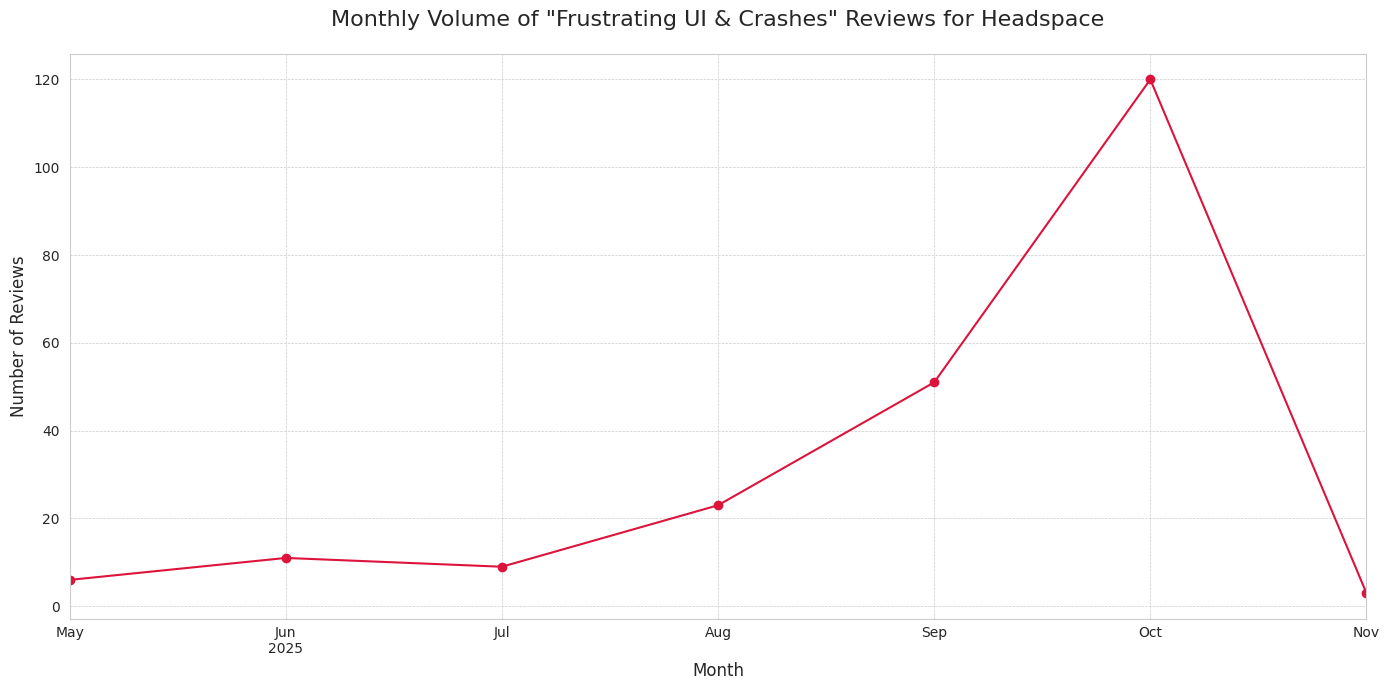

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensuring the combined dataframe is available
# all_analyzed_reviews = pd.concat([...])
# all_analyzed_reviews['date'] = pd.to_datetime(all_analyzed_reviews['date'])


# Step 1: Defining the Topic to Plot
APP_TO_ANALYZE = 'Headspace'

TOPIC_TO_PLOT = 'Frustrating UI & Crashes'


# Step 2: Filtering the dataframe for the Specific Topic

print(f"Attempting to find reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'...")

# This filters the master dataframe to get only the rows that match criteria.
topic_df = all_analyzed_reviews[
    (all_analyzed_reviews['app_name'].str.lower() == APP_TO_ANALYZE.lower()) &
    (all_analyzed_reviews['topic_name'] == TOPIC_TO_PLOT)
]


# Step 3: Checking, Resampling, and Plotting the Data

# This checks if the filtering in Step 2 found anything.
if topic_df.empty:
    # If it's empty, I'll print a helpful warning.
    print("WARNING: NO REVIEWS FOUND")
    print(f"Could not find any reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'.")
    print("Please make sure you have run the `pd.concat` cell and that the topic name is spelled correctly.")

else:
    # If I find reviews, I proceed with plotting.
    print(f"Success!!! Found {len(topic_df)} reviews. Generating plot...")

    # Sets the 'date' column as the index for time-series analysis.
    topic_df = topic_df.set_index('date')

    # Resamples the data by month ('M') and counts the number of reviews in each month.
    monthly_topic_volume = topic_df.resample('M').size()

    # Creating the Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 7))

    monthly_topic_volume.plot(
        kind='line',
        marker='o',
        linestyle='-',
        color='crimson'
    )

    plt.title(f'Monthly Volume of "{TOPIC_TO_PLOT}" Reviews for {APP_TO_ANALYZE.title()}', fontsize=16, pad=20)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

**This chart reveals a significant problem with the Headspace app's stability in 2025, as reviews complaining about a "Frustrating UI & Crashes" surged from July to a peak of 120 reviews in October. The subsequent dramatic drop in November suggests that a fix was successfully deployed, resolving the issue that plagued users for several months. This data points to a major, but temporary, technical failure that was later corrected.**

Attempting to find reviews for App: 'Headspace' and Topic: 'Life-Changing & Daily Routine'...

Success! Found 64 reviews. Generating plot...


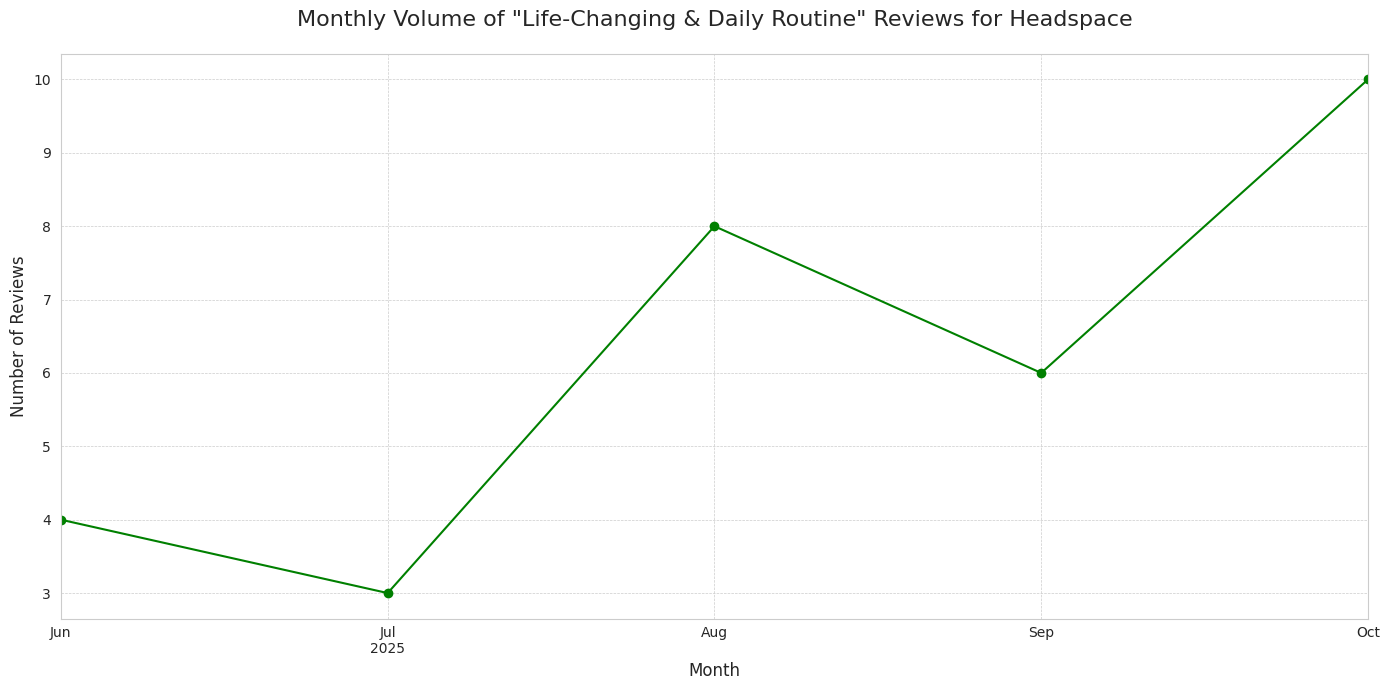

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensures the combined dataframe is available

# Step 1: Defining the Topic to Plot
APP_TO_ANALYZE = 'Headspace'

TOPIC_TO_PLOT = 'Life-Changing & Daily Routine'

# Step 2: Filtering the dataframe for the Specific Topic

print(f"Attempting to find reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'...")

topic_df = all_analyzed_reviews[
    (all_analyzed_reviews['app_name'].str.lower() == APP_TO_ANALYZE.lower()) &
    (all_analyzed_reviews['topic_name'] == TOPIC_TO_PLOT)
]


# Step 3: Checking, Resampling, and Plotting the Data

# This checks if the filtering in Step 2 found anything
if topic_df.empty:
    # If it's empty, I print a warning.
    print("WARNING: NO REVIEWS FOUND")
    print(f"Could not find any reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'.")
    print("Please make sure you have run the `pd.concat` cell and that the topic name is spelled correctly.")

else:
    # If I find reviews, I proceed with plotting.
    print(f"Success!!!! Found {len(topic_df)} reviews. Generating plot...")

    # Setting the 'date' column as the index for time-series analysis.
    topic_df = topic_df.set_index('date')

    # Resampling the data by month ('M') and counting the number of reviews in each month.
    monthly_topic_volume = topic_df.resample('M').size()

    # Creating the Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 7))

    monthly_topic_volume.plot(
        kind='line',
        marker='o',
        linestyle='-',
        color='green'
    )

    plt.title(f'Monthly Volume of "{TOPIC_TO_PLOT}" Reviews for {APP_TO_ANALYZE.title()}', fontsize=16, pad=20)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

**From June to October 2025, the number of Headspace reviews describing the app as "life-changing" or a "daily routine" showed significant upward momentum. After a low of three reviews in July, the volume of these powerful testimonials surged, reaching a peak of ten reviews in October. This trend indicates that a small but growing number of users were finding the app to be an essential and transformative tool in their daily lives during this period.**

Attempting to find reviews for App: 'Calm' and Topic: 'Audio Playback & Download Failures'...

Success! Found 327 reviews. Generating plot...


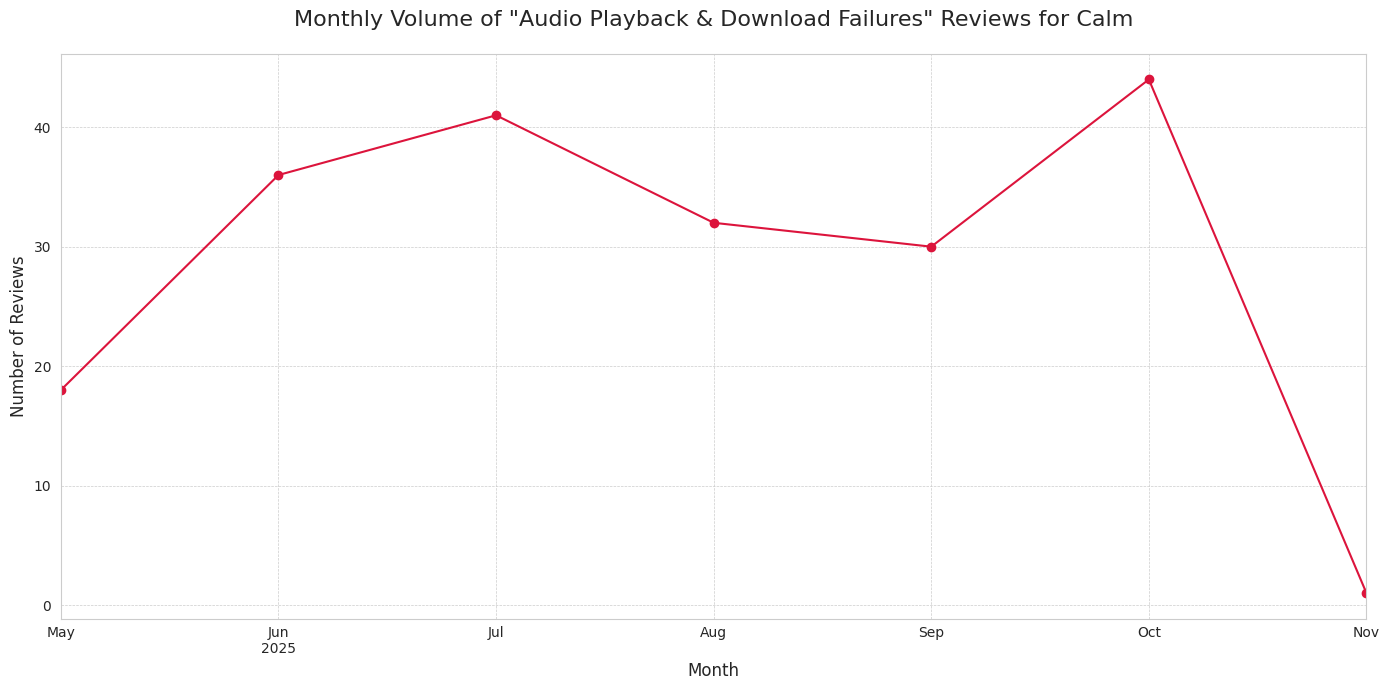

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensuring the combined dataframe is available

# Step 1: Defining the Topic to Plot
APP_TO_ANALYZE = 'Calm'

TOPIC_TO_PLOT = 'Audio Playback & Download Failures'


# Step 2: Filtering the dataframe for the Specific Topic

print(f"Attempting to find reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'...")

topic_df = all_analyzed_reviews[
    (all_analyzed_reviews['app_name'].str.lower() == APP_TO_ANALYZE.lower()) &
    (all_analyzed_reviews['topic_name'] == TOPIC_TO_PLOT)
]


# Step 3: Checking, Resampling, and Plotting the Data

if topic_df.empty:

    print("WARNING: NO REVIEWS FOUND")
    print(f"Could not find any reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'.")
    print("Please make sure you have run the `pd.concat` cell and that the topic name is spelled correctly.")

else:
    print(f"Success!!! Found {len(topic_df)} reviews. Generating plot...")

    topic_df = topic_df.set_index('date')

    monthly_topic_volume = topic_df.resample('M').size()

    # Creating the Plot
    sns.set_style("whitegrid")
    plt.figure(figsize=(14, 7))

    monthly_topic_volume.plot(
        kind='line',
        marker='o',
        linestyle='-',
        color='crimson'
    )

    plt.title(f'Monthly Volume of "{TOPIC_TO_PLOT}" Reviews for {APP_TO_ANALYZE.title()}', fontsize=16, pad=20)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

**The Calm app experienced significant and persistent user complaints regarding "Audio Playback & Download Failures" from May through October 2025, with the volume of negative reviews peaking twice in July and October. However, the problem appears to have been completely resolved in November, as the number of related complaints dropped dramatically to almost zero. This trend suggests a major, recurring technical issue was finally fixed with an update late in the year.**

Attempting to find reviews for App: 'Calm' and Topic: 'Sleep Stories & Soundscapes'...

Success! Found 320 reviews. Generating plot...


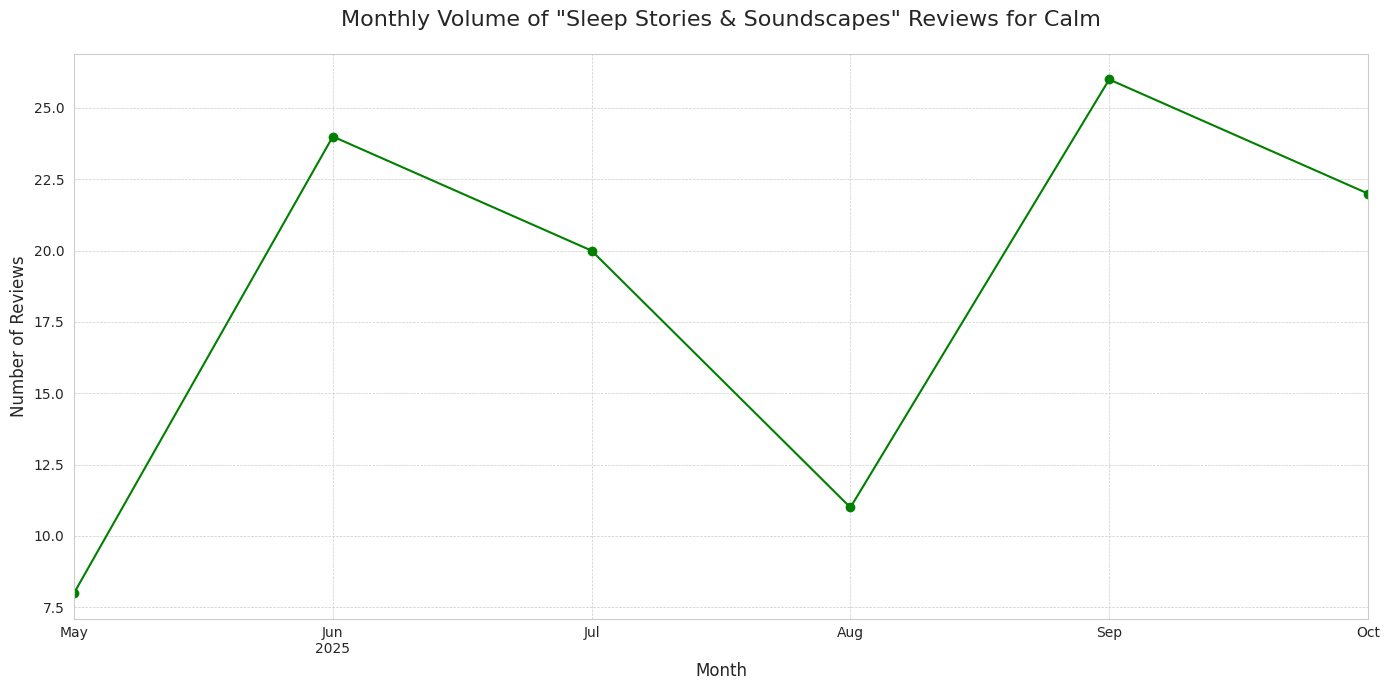

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensuring the combined dataframe is available

#  Step 1: Defining the Topic to Plot

APP_TO_ANALYZE = 'Calm'

TOPIC_TO_PLOT = 'Sleep Stories & Soundscapes'

#  Step 2: Filtering the dataframe for the Specific Topic

print(f"Attempting to find reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'...")

topic_df = all_analyzed_reviews[
    (all_analyzed_reviews['app_name'].str.lower() == APP_TO_ANALYZE.lower()) &
    (all_analyzed_reviews['topic_name'] == TOPIC_TO_PLOT)
]

#  Step 3: Checking, Resampling, and Plotting the Data

if topic_df.empty:
    print(" WARNING: NO REVIEWS FOUND ")
    print(f"Could not find any reviews for App: '{APP_TO_ANALYZE}' and Topic: '{TOPIC_TO_PLOT}'.")
    print("Please make sure you have run the `pd.concat` cell and that the topic name is spelled correctly.")

else:
    print(f"Success! Found {len(topic_df)} reviews. Generating plot...")

    topic_df = topic_df.set_index('date')

    monthly_topic_volume = topic_df.resample('M').size()

    #  Creating the Plot
    sns.set_style("whitegrid"   plt.figure(figsize=(14, 7))

    monthly_topic_volume.plot(
        kind='line',
        marker='o',
        linestyle='-',
        color='green'
    )

    plt.title(f'Monthly Volume of "{TOPIC_TO_PLOT}" Reviews for {APP_TO_ANALYZE.title()}', fontsize=16, pad=20)
    plt.ylabel('Number of Reviews', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

**User reviews for Calm's "Sleep Stories & Soundscapes" were highly popular but also volatile between May and October 2025, showing two significant peaks. After an initial surge to 24 reviews in June, discussion dipped before rocketing to a new high of approximately 26 reviews in September. This pattern highlights that Sleep Stories are a key, recurring driver of user engagement and feedback for the app.**

**You may notice that the months were sorted incorrectly, which I fixed in Google Colab before putting together my final results in a presentation. I used Google Colab at that time because Jupyter Lab was down.**

# Strategic Analysis: Comparison

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [87]:
df_calm_neg['topic_name'].value_counts()

,count
topic_name,
Audio Playback & Download Failures,327
App Stability & Crash Reports,27
Subscription & Cancellation Traps,26
Outliers & Miscellaneous,1


--- Verifying Headspace Mapping ---
battleground_topic
App Bugs & Performance     387
Billing & Monetization     126
NaN                         72
UI & Feature Complaints     71
Name: count, dtype: int64

--- Verifying Calm Mapping ---
battleground_topic
App Bugs & Performance    354
Billing & Monetization     26
NaN                         1
Name: count, dtype: int64

Mapping successful. Generating plot...


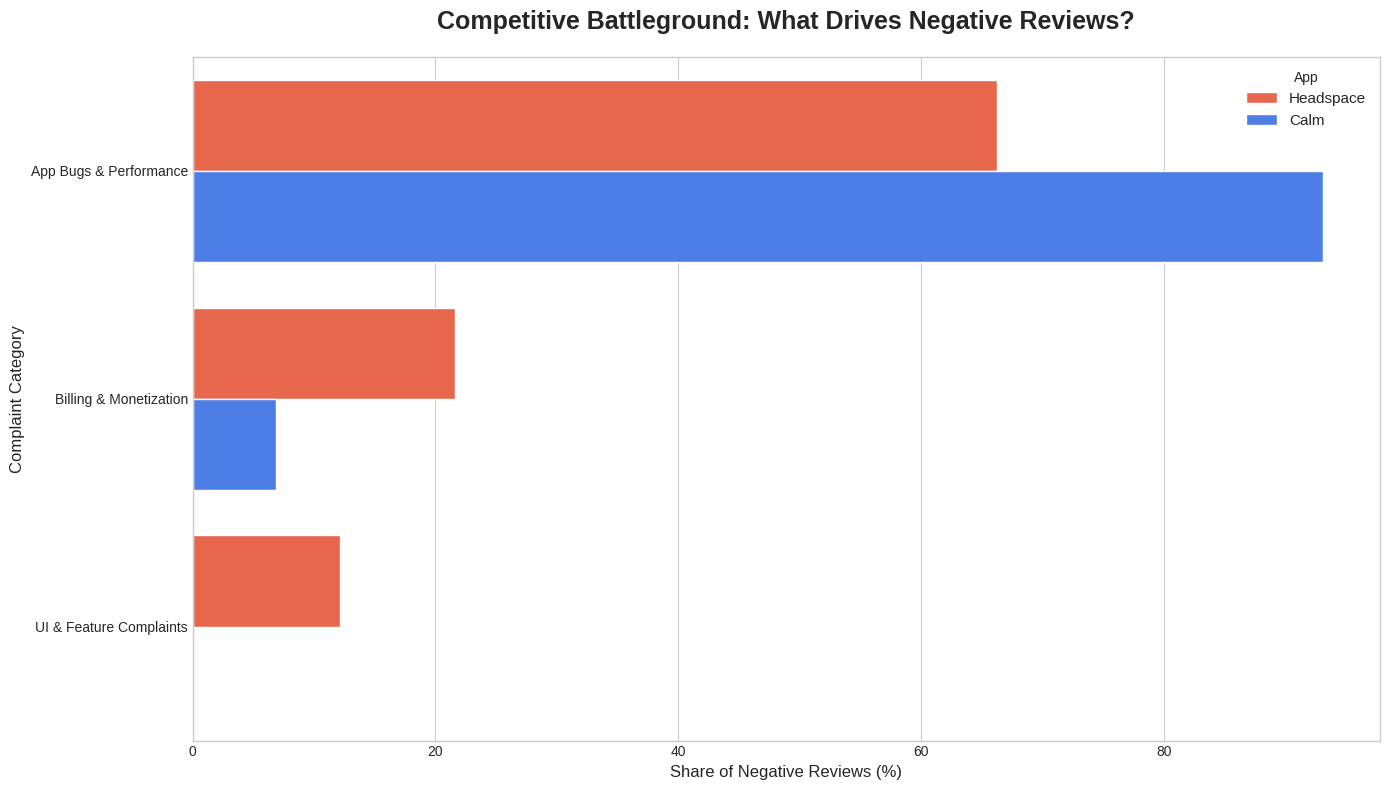

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Step 1: Defining Harmonized "Battleground" Categories

# ***FIX***: I have updated the keys in this dictionary to match the actual topic names.
headspace_to_battleground_map = {
    # Actual Topic Name                  ->  Unified Battleground Category
    'Frustrating UI & Crashes':                   'App Bugs & Performance',
    'Specific Feature Bugs (Sleep)':              'App Bugs & Performance',
    'Critical Bugs & Failures':                   'App Bugs & Performance',
    'Usability Issues (Lock Screen)':             'UI & Feature Complaints',
    'Content & Feature Complaints':               'UI & Feature Complaints',
    'Cancellation & Billing Disputes':            'Billing & Monetization',
    'Subscription & Refund Issues':               'Billing & Monetization',
    'Perceived Value for Money':                  'Billing & Monetization'

}

calm_to_battleground_map = {
    # Original Calm Topic Name                     ->  Battleground Category
    'App Stability & Crash Reports':                  'App Bugs & Performance', # Example
    'Audio Playback & Download Failures':             'App Bugs & Performance', # Example
    'Subscription & Cancellation Traps':              'Billing & Monetization', # Example

}


#  Step 2: Applying Mappings to Create a Battleground Column

df_headspace_neg['battleground_topic'] = df_headspace_neg['topic_name'].map(headspace_to_battleground_map)
df_calm_neg['battleground_topic'] = df_calm_neg['topic_name'].map(calm_to_battleground_map)


#  Step 2.5: ***CRITICAL STEP***
# This shows if the mapping worked. If there is a large number of NaNs, the names are wrong.
print(" Verifying Headspace Mapping ")
print(df_headspace_neg['battleground_topic'].value_counts(dropna=False))
print(" Verifying Calm Mapping ")
print(df_calm_neg['battleground_topic'].value_counts(dropna=False))


#  Step 3: Calculating Percentages and Consolidating Data

# Will drop any rows where the mapping failed (i.e., battleground_topic is NaN)
hs_battleground_counts = df_headspace_neg.dropna(subset=['battleground_topic'])['battleground_topic'].value_counts(normalize=True).mul(100).reset_index()
hs_battleground_counts.columns = ['battleground_topic', 'percentage']
hs_battleground_counts['app_name'] = 'Headspace'

calm_battleground_counts = df_calm_neg.dropna(subset=['battleground_topic'])['battleground_topic'].value_counts(normalize=True).mul(100).reset_index()
calm_battleground_counts.columns = ['battleground_topic', 'percentage']
calm_battleground_counts['app_name'] = 'Calm'

# Combining into a single dataframe for plotting
battleground_df = pd.concat([hs_battleground_counts, calm_battleground_counts])


#  Step 4: Creating the "Battleground" Visualization

if battleground_df.empty:
    print("WARNING: The `battleground_df` is empty. The plot cannot be generated.")
    print("This is likely because the topic names in your maps do not match your data.")
else:
    print("Mapping successful. Generating plot...")
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 8))

    # Creating the grouped bar plot
    sns.barplot(
        data=battleground_df,
        x='percentage',
        y='battleground_topic',
        hue='app_name',
        palette={'Headspace': '#FF5733', 'Calm': '#3375FF'}, # Assigning distinct colors
        orient='h'
    )

    # Adding titles and labels for clarity
    plt.title('Competitive Battleground: What Drives Negative Reviews?', fontsize=18, pad=20, weight='bold')
    plt.xlabel('Share of Negative Reviews (%)', fontsize=12)
    plt.ylabel('Complaint Category', fontsize=12)
    plt.legend(title='App', fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Displaying the final plot
    plt.tight_layout()
    plt.show()

**App bugs and performance issues are the single biggest driver of negative reviews for both Calm and Headspace, though they represent a much larger share of complaints for Calm. Headspace, by contrast, receives a proportionally greater share of its negative reviews from complaints related to billing, monetization, and UI features. This suggests that while technical stability is a key issue for both, Headspace users also frequently express dissatisfaction with the app's payment model and design.**

In [102]:
df_headspace_pos['topic_name'].value_counts()

,count
topic_name,
"Anxiety, Stress & Mood",431
Outliers & Miscellaneous,289
Sleep Quality & Sleepcasts,153
Guided Meditation & Andy's Voice,137
Life-Changing & Daily Routine,64
"Content Variety (Music, Focus)",23
Beginner-Friendly & Easy to Use,22
Pain & Health Management,13
AI Support & New Features,12


--- Verifying Headspace Mapping ---
battleground_topic
Anxiety, Stress, & Health        444
Outliers & Miscellaneous         289
Sleep-Related                    153
Guided Meditation & Narrators    137
Life and Routine Changing         64
Account Support                   24
Content Variety                   23
Ease of Use                       22
Name: count, dtype: int64

--- Verifying Calm Mapping ---
battleground_topic
Outliers & Miscellaneous         354
Sleep-Related                    320
Anxiety, Stress, & Health        316
Guided Meditation & Narrators    139
Life and Routine Changing        113
Content Variety                   65
Ease of Use                       50
Name: count, dtype: int64

Mapping successful. Generating plot...


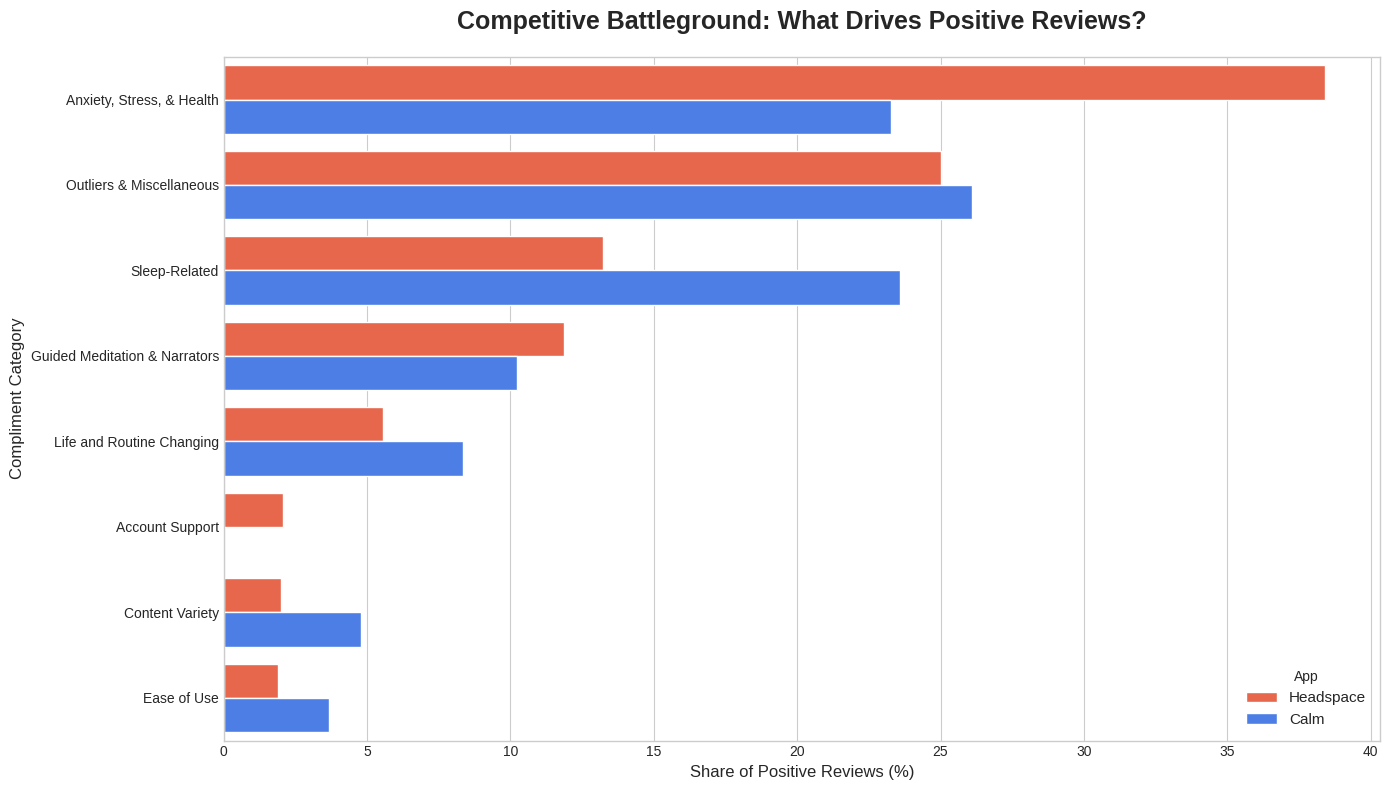

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Defining Harmonized "Battleground" Categories

headspace_to_battleground_map = {
    # Actual Topic Name                  ->  Unified Battleground Category
    'Anxiety, Stress & Mood':                   'Anxiety, Stress, & Health',
    'Outliers & Miscellaneous':                 'Outliers & Miscellaneous',
    'Sleep Quality & Sleepcasts':               'Sleep-Related',
    "Guided Meditation & Andy's Voice":          'Guided Meditation & Narrators',
    'Life-Changing & Daily Routine':            'Life and Routine Changing',
    'Content Variety (Music, Focus)':           'Content Variety',
    'Beginner-Friendly & Easy to Use':          'Ease of Use',
    'Pain & Health Management':                 'Anxiety, Stress, & Health',
    'AI Support & New Features':              'Account Support',
    'Customer Service & Account Issues':        'Account Support'

}

calm_to_battleground_map = {
    # Original Calm Topic Name                     ->  Battleground Category
    'Outliers & Miscellaneous':                'Outliers & Miscellaneous',
    'Sleep Stories & Soundscapes':             'Sleep-Related',
    'Anxiety & Stress Reduction':              'Anxiety, Stress, & Health',
    'Guided Meditations & Daily Calm':         'Guided Meditation & Narrators',
    'Life-Changing & Daily Habit':             'Life and Routine Changing',
    'Content Variety (Music, Masterclass)':    'Content Variety',
    'Beginner-Friendly & Easy Interface':      'Ease of Use',
    'Narrator Voices (Tamara Levitt)':         'Guided Meditation & Narrators',
    'Focus & Productivity':                    'Life and Routine Changing',

}


#  Step 2: Applying Mappings to Create a Battleground Column

df_headspace_pos['battleground_topic'] = df_headspace_pos['topic_name'].map(headspace_to_battleground_map)
df_calm_pos['battleground_topic'] = df_calm_pos['topic_name'].map(calm_to_battleground_map)

#  Step 2.5: ***CRITICAL STEP***
# This shows if the mapping worked. If there is a large number of NaNs, the names are wrong.
print(" Verifying Headspace Mapping ")
print(df_headspace_pos['battleground_topic'].value_counts(dropna=False))
print(" Verifying Calm Mapping ")
print(df_calm_pos['battleground_topic'].value_counts(dropna=False))

#  Step 3: Calculating Percentages and Consolidating Data

# Will drop any rows where the mapping failed (i.e., battleground_topic is NaN)
hs_battleground_counts_pos = df_headspace_pos.dropna(subset=['battleground_topic'])['battleground_topic'].value_counts(normalize=True).mul(100).reset_index()
hs_battleground_counts_pos.columns = ['battleground_topic', 'percentage']
hs_battleground_counts_pos['app_name'] = 'Headspace'

calm_battleground_counts_pos = df_calm_pos.dropna(subset=['battleground_topic'])['battleground_topic'].value_counts(normalize=True).mul(100).reset_index()
calm_battleground_counts_pos.columns = ['battleground_topic', 'percentage']
calm_battleground_counts_pos['app_name'] = 'Calm'

# Combining into a single dataframe for plotting
battleground_df = pd.concat([hs_battleground_counts_pos, calm_battleground_counts_pos])


#  Step 4: Creating the "Battleground" Visualization

if battleground_df.empty:
    print("WARNING: The `battleground_df` is empty. The plot cannot be generated.")
    print("This is likely because the topic names in your maps do not match your data.")
else:
    print("Mapping successful. Generating plot...")
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(14, 8))

    # Creating the grouped bar plot
    sns.barplot(
        data=battleground_df,
        x='percentage',
        y='battleground_topic',
        hue='app_name',
        palette={'Headspace': '#FF5733', 'Calm': '#3375FF'}, # Assigning distinct colors
        orient='h'
    )

    # Adding titles and labels for clarity
    plt.title('Competitive Battleground: What Drives Positive Reviews?', fontsize=18, pad=20, weight='bold')
    plt.xlabel('Share of Positive Reviews (%)', fontsize=12)
    plt.ylabel('Compliment Category', fontsize=12)
    plt.legend(title='App', fontsize=11)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Displaying the final plot
    plt.tight_layout()
    plt.show()

**Headspace's positive reviews are overwhelmingly driven by its effectiveness for "Anxiety, Stress, & Health," which is its single largest category of praise by a wide margin. While Calm also receives compliments in this area, its positive feedback is more diversified, with a distinct competitive advantage in "Sleep-Related" content. Calm also receives a proportionally greater share of praise for its content variety and for being "Life and Routine Changing" compared to Headspace.**


# Strategic Analysis: Voice of the User
**User reviews on the top issues**

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [122]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):
    """
    Filters a dataframe to find and return a sample of original reviews for a specific topic.

    Args:
        df (pd.DataFrame): The dataframe containing reviews and their assigned topics.
                           Must include 'review' and 'battleground_topic' columns.
        topic (str): The exact name of the topic to pull examples for.
        num_examples (int): The number of example reviews to return.

    Returns:
        list: A list of strings, where each string is an example review.
    """
    # Filtering for reviews matching the specified topic
    topic_reviews_df = df[df['battleground_topic'] == topic]

    # Handling cases where the topic doesn't exist or has no reviews
    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    # Taking a sample of the reviews. If fewer reviews than requested exist, will take all of them.
    sample_size = min(num_examples, len(topic_reviews_df))

    # Using .sample() is good for getting a random assortment.
    # Using the 'review' column which contains the original, uncleaned text.
    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

# 1. Defining the target dataframe and topic
TARGET_DF = df_headspace_neg
TARGET_TOPIC = 'App Bugs & Performance'
NUM_EXAMPLES = 4

# 2. Calling the function to get the example reviews
customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

# 3. Printing the results for a report
print(f"[bold]Negative Headspace Reviews. Voice of the Customer: [black]'{TARGET_TOPIC}'[black][/bold]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")


Negative Headspace Reviews. Voice of the Customer: 'App Bugs & Performance'

Example #1:
"Used for years really helped in my stressful job and in life the key to managing this difficult world"

Example #2:
"So helpful, thank you, but also so infuriating! The history and search features are awful. I start a course and it
doesn't record the history and it is sometimes difficult to find again. Please fix this!!"

Example #3:
"usually amazing but In the last few weeks the bug when opening the app is soooo frustrating. I have to open and 
close it multiple times, I'm talking 5+ for it to load correctly."

Example #4:
"Update: now it burns through my battery. 

App’s been broken for weeks. Stop vibe coding! It’s a glorified mp3 player."

**This analysis reveals a clear model error, as the first review is positive praise for the app's effectiveness and was incorrectly categorized as a negative bug report. The other examples, however, are accurately assigned and highlight specific, frustrating technical issues that disrupt the user experience. These correctly categorized reviews point to tangible problems such as loading failures, broken history features, and excessive battery drain.**

**If the customer (business) saw this, I would explain how text analysis saw more negative words than positive, but if they did not, I would just pull Examples 2-4 and grab another random one. Here is how:**

In [123]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):

    topic_reviews_df = df[df['battleground_topic'] == topic]

    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    sample_size = min(num_examples, len(topic_reviews_df))

    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

TARGET_DF = df_headspace_neg
TARGET_TOPIC = 'App Bugs & Performance'
NUM_EXAMPLES = 5

customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

print(f"[bold black]Negative Headspace Reviews. Voice of the Customer: '{TARGET_TOPIC}' [/bold black]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")

Negative Headspace Reviews. Voice of the Customer: 'App Bugs & Performance' 

Example #1:
"Used for years really helped in my stressful job and in life the key to managing this difficult world"

Example #2:
"So helpful, thank you, but also so infuriating! The history and search features are awful. I start a course and it
doesn't record the history and it is sometimes difficult to find again. Please fix this!!"

Example #3:
"usually amazing but In the last few weeks the bug when opening the app is soooo frustrating. I have to open and 
close it multiple times, I'm talking 5+ for it to load correctly."

Example #4:
"Update: now it burns through my battery. 

App’s been broken for weeks. Stop vibe coding! It’s a glorified mp3 player."

Example #5:
"A good app, although some of the buttons are difficult to click if you have 3 button navigation turned on, which 
is a minor frustration."

In [124]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):

    # Filtering for reviews matching the specified topic
    topic_reviews_df = df[df['topic_name'] == topic]

    # Handling cases where the topic doesn't exist or has no reviews
    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    # Taking a sample of the reviews. If fewer reviews than requested exist, will take all of them.
    sample_size = min(num_examples, len(topic_reviews_df))

    # Using .sample() is good for getting a random assortment.
    # Using the 'review' column which contains the original, uncleaned text.
    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

# 1. Defining the target dataframe and topic
TARGET_DF = df_headspace_pos
TARGET_TOPIC = 'Life-Changing & Daily Routine'
NUM_EXAMPLES = 4

# 2. Calling the function to get the example reviews
customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

# 3. Printing the results for a report
print(f"[bold black]Positive Headspace Reviews. Voice of the Customer: '{TARGET_TOPIC}'[/bold black]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")

Positive Headspace Reviews. Voice of the Customer: 'Life-Changing & Daily Routine'

Example #1:
"I loved this app until the most recent update. I use the sleep casts nightly and now they always take forever to 
load and there’s a weird look to it where the ambience change is on the the top and there’s no photo so it has 
generic photo with a line through it"

Example #2:
"if i’m traveling or just can’t fall asleep, i put on a sleep cast and am out in like 5 minutes"

Example #3:
"I had this app a couple yrs ago and i was able to play really any track to go to sleep, NOW EVERYTHING YOU HAVE TO
PAY FOR. EVERY LAST THING IS LOCKED. ITS POINTLESS NOW"

Example #4:
"Edit 2025: everything is now paywalled. This is so ridiculous that something that has been free is now behind a 
paywall. Just offer some free sleep casts but all of them? Wow. 

I’ve had insomnia since high school due to depression and anxiety. I tried falling asleep to music, podcasts, 
hypnosis tracks, everything. Nothing puts me to sleep faster than Sleepcasts. The combination of noise and voice, 
along with the wind downs, are perfect for me to fall asleep to. I’ve never made it a full 10 minutes into the 
casts, which is a miracle for me. I also love that you can turn up more sounds or voice. My only suggestion is 
this: When going to the sleep menu, everything is in dark tones which is easy on the eyes and great for getting 
into a sleep mood. However, when you click on your selection, the screen goes white and it’s bright. I would change
this to match the rest of the lighting, because this just alerts my eyes and brain again (if that makes sense). I 
just want to see it dark and purple like the rest of the sleep stuff."

**This sample of reviews highlights a significant classification error, as most of these reviews are negative complaints rather than positive endorsements. The classification error comes from the reviews being edited or mixed. The reviews show that while Headspace's "Sleepcast" feature is considered a genuinely life-changing tool for users with sleep issues, this praise is buried under frustration. The primary complaints center on recent updates that have put this critical content behind a paywall and introduced technical bugs and undesirable UI changes.**

In [125]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):

    # Filtering for reviews matching the specified topic
    topic_reviews_df = df[df['topic_name'] == topic]

    # Handling cases where the topic doesn't exist or has no reviews
    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    # Taking a sample of the reviews. If fewer reviews than requested exist, will take all of them.
    sample_size = min(num_examples, len(topic_reviews_df))

    # Using .sample() is good for getting a random assortment.
    # Using the 'review' column which contains the original, uncleaned text.
    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

# 1. Defining the target dataframe and topic
TARGET_DF = df_calm_neg
TARGET_TOPIC = 'Audio Playback & Download Failures'
NUM_EXAMPLES = 4

# 2. Calling the function to get the example reviews
customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

# 3. Printing the results for a report
print(f"[bold black]Negative Calm Reviews. Voice of the Customer: '{TARGET_TOPIC}'[/bold black]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")

Negative Calm Reviews. Voice of the Customer: 'Audio Playback & Download Failures'

Example #1:
"I canceled my subscription a long time ago and they charged me the full year subscription anyway. I reached out to
customer service and... crickets. I have proof that I canceled and they are nonresponsive. Ironically the "Calm" 
app is causing me undue stress and anxiety because 70 dollars is a very big deal to me right now for them to just 
take from me. Beware folks."

Example #2:
"Stop spamming emails and notifications"

Example #3:
"changed R decreased STRESS!"

Example #4:
"If a music choice has multiple songs it does not automatically advance to the next song.  This, too, is annoying 
when resting and have to be disturbed to go to the next song."

In [ ]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):

    # Filtering for reviews matching the specified topic
    topic_reviews_df = df[df['topic_name'] == topic]

    # Handling cases where the topic doesn't exist or has no reviews
    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    # Taking a sample of the reviews. If fewer reviews than requested exist, will take all of them.
    sample_size = min(num_examples, len(topic_reviews_df))

    # Using .sample() is good for getting a random assortment.
    # Using the 'review' column which contains the original, uncleaned text.
    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

# 1. Defining the target dataframe and topic
TARGET_DF = df_calm_pos
TARGET_TOPIC = 'Sleep Stories & Soundscapes'
NUM_EXAMPLES = 4

# 2. Calling the function to get the example reviews
customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

# 3. Printing the results for a report
print(f"[bold black]Positive Calm Reviews. Voice of the Customer: '{TARGET_TOPIC}'[/bold black]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")

**This group of users feel betrayed and frustrated when the experience is disrupted by technical bugs, poor design choices, or business decisions like moving essential content behind a paywall. Ultimately, there is a powerful tension between the immense value users get from the content and their frustration when the app's execution fails to deliver that content reliably.**

In [126]:
import pandas as pd

def get_voice_of_customer_examples(df, topic, num_examples=3):

    # Filtering for reviews matching the specified topic
    topic_reviews_df = df[df['topic_name'] == topic]

    # Handling cases where the topic doesn't exist or has no reviews
    if topic_reviews_df.empty:
        print(f"Warning: No reviews found for topic '{topic}'.")
        return []

    # Taking a sample of the reviews. If fewer reviews than requested exist, will take all of them.
    sample_size = min(num_examples, len(topic_reviews_df))

    # Using .sample() is good for getting a random assortment.
    # Using the 'review' column which contains the original, uncleaned text.
    example_reviews = topic_reviews_df.sample(sample_size, random_state=42)['review'].tolist()

    return example_reviews

# 1. Defining the target dataframe and topic
TARGET_DF = df_calm_pos
TARGET_TOPIC = 'Sleep Stories & Soundscapes'
NUM_EXAMPLES = 4

# 2. Calling the function to get the example reviews
customer_quotes = get_voice_of_customer_examples(
    df=TARGET_DF,
    topic=TARGET_TOPIC,
    num_examples=NUM_EXAMPLES
)

# 3. Printing the results for a report
print(f"[bold black]Positive Calm Reviews. Voice of the Customer: '{TARGET_TOPIC}'[/bold black]")

if customer_quotes:
    for i, quote in enumerate(customer_quotes, 1):
        print(f'Example #[black]{i}[black/]:\n[blue]"{quote.strip()}[blue]"\n')
else:
    print("No quotes to display.")

Positive Calm Reviews. Voice of the Customer: 'Sleep Stories & Soundscapes'

Example #1:
"Changing my update after reusing the app after a long time. The person who added the vibrate settings to the 
"Breathing Exercises" section is a genius who should be given a raise. Such a simple idea for people who want to 
meditate in silence, with their eyes closed. But I wish all the exercises in Breathing Exercises had customisable 
timers. Why can I only do the Energize exercise for 5 minutes at a time?"

Example #2:
"I’m a kid and I love this app I love cálm  because it helps me sleep faster and stay awake at school"

Example #3:
"I have had this for 6 years now. I love it. I have overactive thinking. I put some sounds or music no sounds. 
Helps me stay focused. M"

Example #4:
"Since joining Calm I have been able to put a little more focus in my life, It is available and I can refer to 
favorite sessions whenever."

**These reviews highlight the diverse ways users integrate Calm into their lives to achieve different goals. While one user praises its ability to help them sleep, others emphasize its value as a tool for improving daily focus and managing an overactive mind. The feedback also shows a deep appreciation for specific, thoughtful features like vibration settings for breathing exercises, even as users suggest further customization.** 

## Topic Modeling Overview

While both Headspace and Calm foster deep loyalty among users who find their content life-changing, they are failing these users in critically different ways. Headspace's primary weakness is a fundamentally unstable app, with an epidemic of crashes and bugs that undermine its core function. Calm, in contrast, suffers from a massive, persistent failure in its core content delivery system, with audio playback and download issues dominating negative feedback. For Headspace, the risk is alienating users who depend on it for their daily routine; for Calm, it's a failure to deliver the very product users pay for.

### Deep Dive: The Headspace Experience

**What Users Love:** Headspace excels at becoming an indispensable part of a user's daily routine. Positive feedback is dominated by testimonials describing the app as a "life-changing" tool for managing anxiety, stress, and insomnia. Users praise the tangible, routine-based outcomes, with specific features like Sleepcasts being celebrated as "miracles" for helping them sleep.

**What Users Hate:** Negative sentiment is overwhelmingly driven by app instability. A full 50% of complaints target a frustrating UI, constant crashes, bugs that prevent course history from being saved, and severe battery drain. The second major pain point is the business model, with users expressing frustration over aggressive paywalls and confusing subscription management.

**The "Advocate Risk":** The most critical insight is the volume of feedback from long-time, loyal users who express both love for the content and extreme frustration with the app's performance. These are dedicated advocates being pushed to their limits, representing a significant churn risk directly attributable to poor technical quality.


### Deep Dive: The Calm Experience

**What Users Love:** Calm's user base is built on the strength of its unique and effective content, particularly its Sleep Stories and Soundscapes. Positive reviews are filled with passionate testimonials from users who rely on this content to manage insomnia and an "overactive mind." Beyond sleep, users also praise the app's utility for improving daily focus and appreciate thoughtful design choices that show a deep understanding of user needs.

**What Users Hate:** The overwhelming source of user frustration is a singular, critical failure: the inability to reliably play audio. This core function is described as consistently failing, with audio stopping mid-session, downloaded content not playing, and the player being generally buggy. This is uniquely infuriating for the user base, as it often disrupts the very state of relaxation or sleep the app is supposed to provide.

**The "Frustrated Enthusiast":** Calm's version of the "Love it, but..." user is one who is deeply attached to the content but blocked by the app's execution. Their frustration is not with the app's overall stability but with the failure of the core content delivery system. These reviews reveal a powerful tension: users feel the content is life-changing but are exasperated that the app consistently fails at its one job.

### The Competitive Landscape: Headspace vs. Calm

**Positive Battleground:** Headspace's brand strength is centered on being a tool for Anxiety, Stress, & Health as part of a daily routine. Calm's distinct competitive advantage lies in its Sleep-Related content, with its Sleep Stories and Soundscapes driving massive engagement and loyalty.

**Negative Battleground:** The weaknesses are starkly different. Headspace's reputation is damaged by app-wide performance failures (crashes, UI bugs). Calm's is defined by a singular, critical feature failure (audio playback). This indicates that while both have quality control issues, they manifest in different parts of the user experience—Headspace in the container, Calm in the content delivery.

### Strategic Recommendations

**For Headspace:**

1. Declare an 'App Health' Initiative: Pause non-essential feature development to allocate all necessary engineering resources to resolving stability, performance (battery drain), and core functionality bugs. The singular goal should be making the app fast and reliable.
2. Overhaul the Subscription Experience: Redesign the subscription and cancellation flow for maximum transparency to address user anger around billing. Clearly communicate the value proposition and what content is free versus paid to manage user expectations.
3. Establish a "Power User" Feedback Channel: Create a formal program for loyal users to report bugs. This provides high-quality QA and helps rebuild trust with frustrated advocates.

**For Calm:**

1. Launch an "Audio Reliability" Task Force: The #1 priority must be fixing the core audio player. A dedicated engineering team should be tasked with a root-cause analysis and resolution of playback failures, including streaming, downloads, and background play. The app's core function must be flawless.
2. Amplify the Core Strength: Double down on what users love. Marketing, content acquisition, and product strategy should be laser-focused on reinforcing Calm's position as the undisputed leader in content for Sleep and Focus. This is their key differentiator and most powerful driver of positive sentiment.
3. Implement a Content-First Support Model: Train the support team to specifically and empathetically handle audio playback failures. The process should acknowledge the user's interrupted experience (e.g., "We're so sorry your Sleep Story was interrupted") and provide a streamlined path to resolution, turning a moment of extreme frustration into a positive support interaction.

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

# ABSA

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [1]:
!pip install -U openai pydantic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.6 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.27.1
    Uninstalling pydantic_core-2.27.1:
      Successfully uninstalled pydantic_core-2.27.1
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.10.3
    Uninstalling pydantic-2.10.3:
      Successfully uninstalled pydantic-2.10.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [openai]2m4/5 [openai]c]


In [2]:
import os
from openai import OpenAI
from pydantic import BaseModel

# --- 1. Set up your API Key ---
os.environ["OPENAI_API_KEY"] = "********"
client = OpenAI()

# --- 2. Define the exact structure we want back ---
class AspectResult(BaseModel):
    aspect: str
    sentiment: str # E.g., "Positive", "Negative", "Neutral"
    reason: str

class ReviewAnalysis(BaseModel):
    aspects: list[AspectResult]

# --- 3. Create the extraction function ---
def extract_absa(review_text):
    # System prompt telling the AI exactly what its job is
    system_prompt = """
    You are an expert Aspect-Based Sentiment Analyzer.
    Read the app review and extract the specific features/aspects mentioned.
    For each aspect, determine the sentiment (Positive, Negative, or Neutral) and
    provide a short reason based ONLY on the text.
    Pay attention to emojis as they often convey sentiment.
    """

    try:
        response = client.beta.chat.completions.parse(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": review_text}
            ],
            response_format=ReviewAnalysis,
            temperature=0.0 # Keep it highly deterministic and factual
        )

        # Return the parsed data
        return response.choices[0].message.parsed

    except Exception as e:
        print(f"Error processing review: {e}")
        return None

# --- 4. Test it! ---
test_review = "The sleep stories are amazing 😴, but I was charged unexpectedly after the free trial 😡."

print(f"Original Review: {test_review}\n")
results = extract_absa(test_review)

if results:
    for item in results.aspects:
        print(f"Aspect: {item.aspect}")
        print(f"Sentiment: {item.sentiment}")
        print(f"Reason: {item.reason}")
        print("-" * 30)


Original Review: The sleep stories are amazing 😴, but I was charged unexpectedly after the free trial 😡.

Aspect: sleep stories
Sentiment: Positive
Reason: The reviewer describes the sleep stories as 'amazing', indicating a positive sentiment.
------------------------------
Aspect: charging after free trial
Sentiment: Negative
Reason: The reviewer expresses frustration with being charged unexpectedly, as indicated by the angry emoji.
------------------------------


In [3]:
import pandas as pd
from tqdm.auto import tqdm

# 1. Loading the CLEANED dataset
df = pd.read_csv("Multi_Month_App_Reviews_CLEANED.csv")

# 2. Taking a small sample to test (e.g., the first 20 rows)
#df_sample = df.head(20).copy()
df_sample = df

# 3. Creating an empty list to hold our flattened data
absa_data = []

# 4. Looping through the sample and extract aspects
print("Extracting ABSA features...")
for index, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
    review_text = row['review']

    # Skipping any empty reviews
    if pd.isna(review_text) or str(review_text).strip() == "":
        continue

    # Calling my LLM function
    parsed_result = extract_absa(str(review_text))

    if parsed_result:
        for item in parsed_result.aspects:
            absa_data.append({
                "original_review_index": index,
                "app_name": row.get('app_name'),
                "source": row.get('source'),
                "month_number": row.get('month_number'),
                "date": row.get('date'),
                "rating": row.get('rating'),
                "review_text": review_text,
                "aspect": item.aspect,
                "sentiment": item.sentiment,
                "reason": item.reason
            })

# 5. Converting to a DataFrame and looking at the results!
absa_df = pd.DataFrame(absa_data)
absa_df.head(10)

Extracting ABSA features...


  0%|          | 0/5564 [00:00<?, ?it/s]

,original_review_index,app_name,source,month_number,date,rating,review_text,aspect,sentiment,reason
0,0,Headspace,Apple App Store,1,None,2,I really wish the sleepcasts had better compat...,sleepcasts compatibility,Negative,The user expresses a wish for better compatibi...
1,0,Headspace,Apple App Store,1,None,2,I really wish the sleepcasts had better compat...,HomePods performance,Negative,The user reports issues with the HomePods not ...
2,0,Headspace,Apple App Store,1,None,2,I really wish the sleepcasts had better compat...,iOS update,Negative,The user states that the new iOS update has ca...
3,0,Headspace,Apple App Store,1,None,2,I really wish the sleepcasts had better compat...,voice and sound balance,Negative,The user mentions problems with balancing voic...
4,1,Headspace,Apple App Store,1,None,1,There are some glaring UI bugs and UX issues w...,UI bugs,Negative,"The reviewer mentions 'glaring UI bugs', indic..."
5,1,Headspace,Apple App Store,1,None,1,There are some glaring UI bugs and UX issues w...,UX issues,Negative,The mention of 'UX issues' suggests problems w...
6,1,Headspace,Apple App Store,1,None,1,There are some glaring UI bugs and UX issues w...,Customer support,Negative,The reviewer expresses frustration with the cu...
7,1,Headspace,Apple App Store,1,None,1,There are some glaring UI bugs and UX issues w...,Bug fix request option,Negative,The inability to find an option to submit a bu...
8,1,Headspace,Apple App Store,1,None,1,There are some glaring UI bugs and UX issues w...,Bot responses,Negative,The reviewer is unhappy with receiving only 'b...
9,2,Headspace,Apple App Store,1,None,2,Headspace ultimately comes down to breathing —...,Breathing exercises,Neutral,The review states that breathing is fine but d...


In [4]:
# --- IMMEDIATE NEXT STEP: Save my ABSA results ---
absa_df.to_csv("ABSA_Results.csv", index=False)
print("ABSA extraction complete. Results saved to ABSA_Results.csv")

ABSA extraction complete. Results saved to ABSA_Results.csv


In [20]:
absa_df.to_csv("ABSA_Results.csv", index=False, encoding='utf-8')
print("ABSA extraction complete. Results saved to ABSA_Results.csv with UTF-8 encoding.")

ABSA extraction complete. Results saved to ABSA_Results.csv with UTF-8 encoding.


In [5]:
import pandas as pd
absa = pd.read_csv("ABSA_Results.csv")

Top negative complaints

In [6]:
absa[absa["sentiment"]=="Negative"]["aspect"].value_counts().head(30)

aspect
User Experience         364
App Performance         295
Pricing                 292
Customer Support        193
Overall Experience      145
App Stability           143
Value for Money         128
Customer Service        108
Performance             108
App functionality       104
Loading Speed            95
Functionality            91
App Functionality        79
Cost                     76
Navigation               75
User experience          63
Free Trial               60
Subscription             59
User Interface           59
Usability                58
Cancellation Process     53
App performance          49
Bugs                     48
Paywall                  46
Content Availability     44
Subscription Model       44
User Interface (UI)      43
Subscription Value       42
app performance          41
Price                    41
Name: count, dtype: int64

Compare top 20 negative complaints by app

In [14]:
(
    absa[absa["sentiment"]=="Negative"]
    .groupby(["app_name", "aspect"]).size()
    .groupby(level=0, group_keys=False)
    .nlargest(20)
)


app_name   aspect              
Calm       Pricing                 205
           User Experience         119
           Customer Support         93
           Overall Experience       72
           Customer Service         52
           Value for Money          47
           Cost                     43
           Cancellation Process     38
           Free Trial               32
           Price                    32
           Functionality            30
           App Performance          29
           Ads                      28
           Content Availability     28
           App Functionality        27
           Performance              27
           User experience          26
           App functionality        25
           Subscription Model       23
           Billing                  20
Headspace  App Performance         266
           User Experience         245
           App Stability           126
           Customer Support        100
           Pricing              

Monthly trends (which problems are getting better/worse) *Limitation

In [8]:
absa[absa["sentiment"]=="Negative"].groupby(["month_number", "aspect"]).size()

month_number  aspect             
1             'today' layout         1
              14-day trial           1
              7 day free trial       1
              7 day trial            1
              7-day trial push       1
                                    ..
12            User Experience        2
              User Interface (UI)    1
              Wind Down Exercises    1
              Woke Ideology          1
              paid content           1
Length: 4200, dtype: int64

Pull example reviews for a specific complaint

In [17]:
def show_examples(aspect):
    return absa[(absa["sodium bromide vs table salt"]==aspect) & (absa["sentiment"]=="Negative")]["review_text"].head(10)

# Example:
# show_examples("sleep stories")


Full sentiment distribution by aspect. See which features are loved, hated, or mixed.

In [12]:
summary = absa.groupby(["aspect", "sentiment"]).size().unstack(fill_value=0)
summary.head(20)


sentiment,Mixed,Negative,Neutral,Positive
aspect,,,,
'today' layout,0,1,0,0
10 Minute Practice,0,0,0,1
10m meditations with Andy,0,0,1,0
14-day trial,0,1,0,0
30 day meditation,0,0,0,1
30 day trial,0,0,1,0
30 minute limit to Ebb chat sessions,0,1,0,0
30-day free trial,0,1,0,0
30-day trial,0,0,0,1


Visualize the top 20 negative aspects

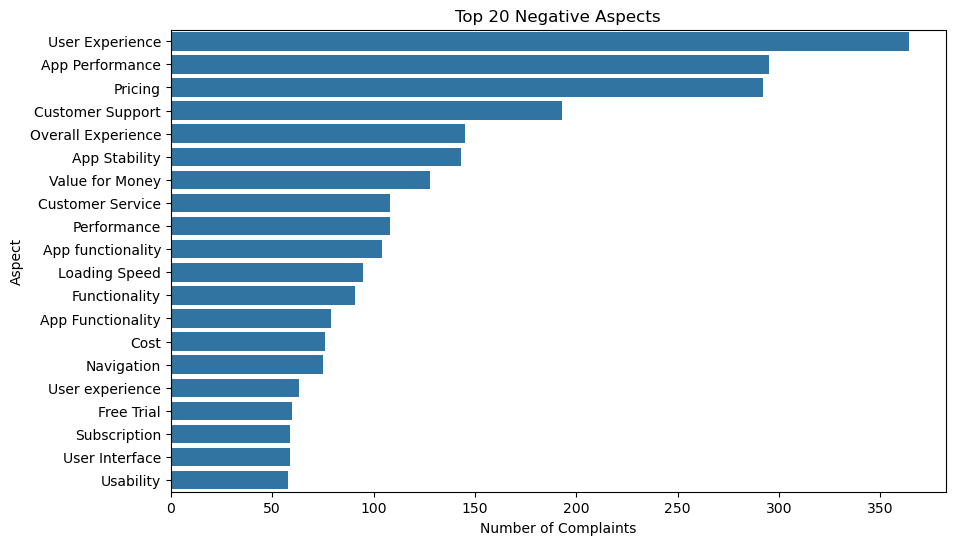

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

top_aspects = absa[absa["sentiment"]=="Negative"]["aspect"].value_counts().head(20)

plt.figure(figsize=(10,6))
sns.barplot(y=top_aspects.index, x=top_aspects.values)
plt.title("Top 20 Negative Aspects")
plt.xlabel("Number of Complaints")
plt.ylabel("Aspect")
plt.show()


Grouping Aspects

In [15]:
neg_aspects = sorted(absa[absa["sentiment"]=="Negative"]["aspect"].unique())
for a in neg_aspects:
    print(a)

'today' layout
14-day trial
30 minute limit to Ebb chat sessions
30-day free trial
360 Immersion
7 day free trial
7 day trial
7-day trial push
8-hr Radios
8h sleep sounds
A/B Testing
AI
AI 'Ebb' nags
AI Assistant
AI Bot 'Ebb'
AI Chat Feature
AI Chatbot
AI Chatbot Feature
AI Chatbot Support
AI Companion
AI Companion Feature
AI Conversation
AI Customer Service
AI Customer Service Feature
AI Ebb
AI Ebb feature
AI Feature
AI Features
AI Functionality
AI Helper
AI Implementation
AI Integration
AI Interaction
AI Management Agent
AI Personal Data Collection
AI Recommendations
AI Suggestions
AI Therapist
AI Therapist Feature
AI Therapy
AI Tool
AI agent
AI and Paid Therapy
AI and counseling options
AI and therapy features
AI and therapy tools
AI bot
AI chat
AI chat and selling coaches
AI chat bot
AI chat bot implementation
AI chatbot
AI chatbots
AI companion
AI content
AI customer support
AI feature
AI feature (Ebb)
AI feature placement
AI features
AI generated recordings
AI guided meditation
A

In [19]:
neg_counts = absa[absa["sentiment"]=="Negative"]["aspect"].value_counts()
print(neg_counts)
neg_counts.to_csv("Negative_Aspects_Full_List.csv")

aspect
User Experience           364
App Performance           295
Pricing                   292
Customer Support          193
Overall Experience        145
                         ... 
Android app update          1
Daily 'To Do' List          1
Breaths Renumbering         1
Morning Wakeup Section      1
Clitching                   1
Name: count, Length: 3441, dtype: int64


# Aspect Overwhelm and File Change

I am unhappy with how many aspects there are. It is overwhelming and a limitation. While too few aspects and too broad of aspects may be a limitation as well, I would prefer that, as we can see things a little more clearly. I consolidated the aspects in Excel using formulas and organization. I chose the following aspects: 
- Account and Log In Bugs
- Ads
- AI
- Bugs and Crashing
- Company Optics
- Competition
- Content
- Customer Support
- Emails
- Feature Request
- Integration
- Life Improvement
- Likes or Dislikes
- Meditation
- Notifications
- Personal Data
- Pricing
- Refunds
- Therapy
-UI

I can elaborate a bit more on each aspect as they are broad, but these are the aspects that remain. 

In [4]:
import pandas as pd

absa_df = pd.read_csv("ABSA_Resultsfinal.csv", encoding='utf-8')

absa_df.head()

,original_review_index,app_name,source,month_number,date,rating,review_text,aspect,sentiment,reason,original aspect
0,223,Headspace,Apple App Store,1,NaN,1,Had account in the past. Decided to open a fam...,Account and Log In Bugs,Negative,The user cannot access their account despite h...,Account Access
1,223,Headspace,Apple App Store,1,NaN,1,Had account in the past. Decided to open a fam...,Account and Log In Bugs,Negative,The app is described as unusable due to persis...,App Usability
2,292,Headspace,Apple App Store,1,NaN,2,Iâ€™ve yet to be able to access the iPad app w...,Account and Log In Bugs,Negative,The user is unable to access the app and is fr...,App Accessibility
3,445,Headspace,Apple App Store,1,NaN,1,I thought it would be as simple as creating an...,Account and Log In Bugs,Negative,The user found the account creation process to...,Account Creation Process
4,445,Headspace,Apple App Store,1,NaN,1,I thought it would be as simple as creating an...,Account and Log In Bugs,Negative,The account being locked prevented the user fr...,Account Locking


In [5]:
# --- Top Negative Aspects ---
print("🚨 Top Negative Aspects (What's driving bad reviews) 🚨")
print("-" * 50)
top_negative = absa_df[absa_df["sentiment"] == "Negative"]["aspect"].value_counts().head(15)
print(top_negative)

print("\n\n") 

# --- Top Positive Aspects ---
print("🌟 Top Positive Aspects (What users love) 🌟")
print("-" * 50)
top_positive = absa_df[absa_df["sentiment"] == "Positive"]["aspect"].value_counts().head(15)
print(top_positive)

🚨 Top Negative Aspects (What's driving bad reviews) 🚨
--------------------------------------------------
aspect
Bugs and Crashing          2256
Pricing                    1349
Likes or Dislikes           778
UI                          710
Content                     693
Refunds                     645
Customer Support            506
Meditation                  221
AI                          158
Life Improvement            146
Account and Log In Bugs     142
Ads                         112
Integration                 103
Feature Request              73
Company Optics               50
Name: count, dtype: int64



🌟 Top Positive Aspects (What users love) 🌟
--------------------------------------------------
aspect
Content              1282
Life Improvement     1268
Likes or Dislikes     731
Meditation            428
UI                    133
Bugs and Crashing     124
Pricing               113
Customer Support       31
Refunds                25
Feature Request        21
AI                

There is a limitation because there are more reviews that belong in some of the aspect categories with low numbers, but I was working quickly. 

In [7]:
# --- Compare Negative Aspects by App ---
print("🚨 Top Negative Aspects: Calm vs. Headspace 🚨")
print("-" * 50)
neg_comparison = (
    absa_df[absa_df["sentiment"] == "Negative"]
    .groupby(["app_name", "aspect"])
    .size()
    .groupby(level=0, group_keys=False)
    .nlargest(10)
)
print(neg_comparison)

print("\n\n")

# --- Compare Positive Aspects by App ---
print("🌟 Top Positive Aspects: Calm vs. Headspace 🌟")
print("-" * 50)
pos_comparison = (
    absa_df[absa_df["sentiment"] == "Positive"]
    .groupby(["app_name", "aspect"])
    .size()
    .groupby(level=0, group_keys=False)
    .nlargest(10)
)
print(pos_comparison)


🚨 Top Negative Aspects: Calm vs. Headspace 🚨
--------------------------------------------------
app_name   aspect                 
Calm       Pricing                     775
           Bugs and Crashing           419
           Refunds                     369
           Content                     326
           Likes or Dislikes           304
           Customer Support            235
           UI                          143
           Ads                          86
           Account and Log In Bugs      75
           Life Improvement             72
Headspace  Bugs and Crashing          1837
           Pricing                     574
           UI                          567
           Likes or Dislikes           474
           Content                     367
           Refunds                     276
           Customer Support            271
           Meditation                  175
           AI                          154
           Integration                  89
dtype: in

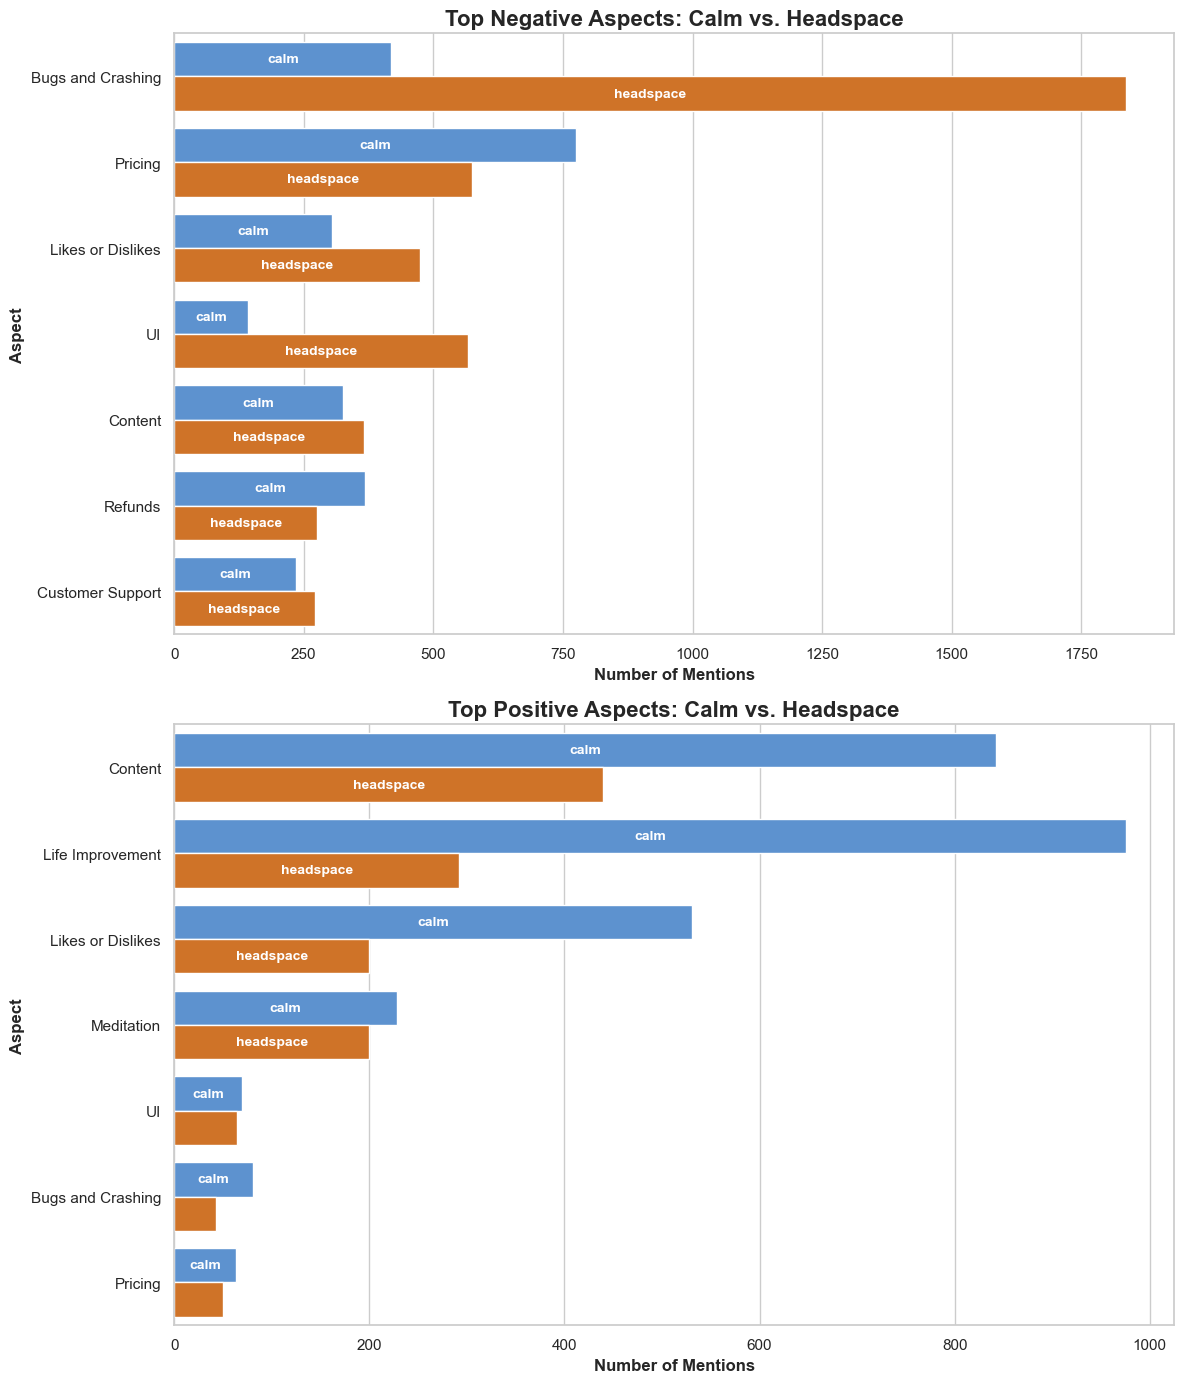

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style
sns.set_theme(style="whitegrid")

# --- 1. Preparing Negative Data ---
top_neg_aspects = absa_df[absa_df['sentiment'] == 'Negative']['aspect'].value_counts().nlargest(7).index
neg_plot_data = absa_df[(absa_df['sentiment'] == 'Negative') & (absa_df['aspect'].isin(top_neg_aspects))]

# --- 2. Preparing Positive Data ---
top_pos_aspects = absa_df[absa_df['sentiment'] == 'Positive']['aspect'].value_counts().nlargest(7).index
pos_plot_data = absa_df[(absa_df['sentiment'] == 'Positive') & (absa_df['aspect'].isin(top_pos_aspects))]

# --- 3. Creating the Charts ---
fig, axes = plt.subplots(2, 1, figsize=(12, 14))
app_colors = {'Calm': '#4A90E2', 'Headspace': '#EB700C'}

# Plot Negative
sns.countplot(
    data=neg_plot_data, 
    y='aspect', 
    hue='app_name', 
    hue_order=['Calm', 'Headspace'], # Guarantees Calm is 1st (container 0), Headspace is 2nd (container 1)
    order=top_neg_aspects, 
    palette=app_colors, 
    ax=axes[0]
)
axes[0].set_title('Top Negative Aspects: Calm vs. Headspace', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Number of Mentions', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Aspect', fontsize=12, fontweight='bold')

# Plot Positive
sns.countplot(
    data=pos_plot_data, 
    y='aspect', 
    hue='app_name', 
    hue_order=['Calm', 'Headspace'], 
    order=top_pos_aspects, 
    palette=app_colors, 
    ax=axes[1]
)
axes[1].set_title('Top Positive Aspects: Calm vs. Headspace', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Number of Mentions', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Aspect', fontsize=12, fontweight='bold')

# --- 4. Adding custom text to the center of the bars ---
def add_app_labels(ax):
    # 1. Adding "calm" to the first hue category (ax.containers[0])
    for bar in ax.containers[0]:
        width = bar.get_width()
        if width > 40:  
            ax.text(
                width / 2, bar.get_y() + bar.get_height() / 2, 'calm',
                ha='center', va='center', color='white', fontweight='bold', fontsize=10
            )
            
    # 2. Adding "headspace" to the second hue category (ax.containers[1])
    for bar in ax.containers[1]:
        width = bar.get_width()
        if width > 80:  # Slightly larger threshold because "headspace" is a longer word
            ax.text(
                width / 2, bar.get_y() + bar.get_height() / 2, 'headspace',
                ha='center', va='center', color='white', fontweight='bold', fontsize=10
            )

# Applying the labels to both subplots
add_app_labels(axes[0])
add_app_labels(axes[1])

axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

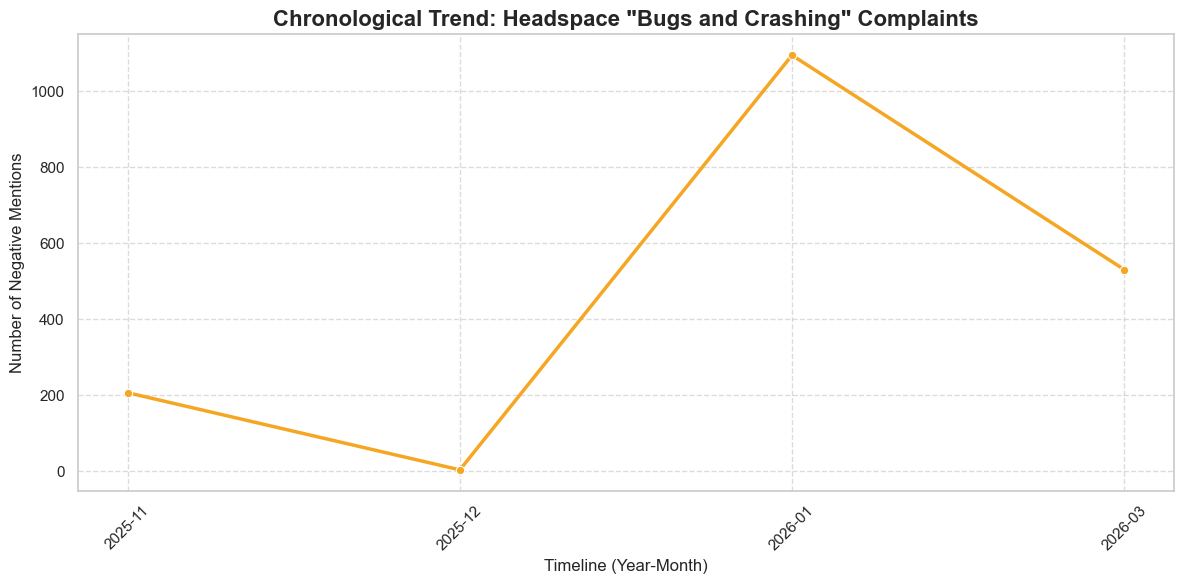

Chronological breakdown of Headspace Bugs and Crashing mentions:
year_month
2025-11     207
2025-12       4
2026-01    1095
2026-03     531
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtering the data for Headspace's Negative Bug reviews
headspace_bugs = absa_df[
    (absa_df['app_name'] == 'Headspace') & 
    (absa_df['aspect'] == 'Bugs and Crashing') & 
    (absa_df['sentiment'] == 'Negative')
].copy()

# 2. Fixing the chronological sorting issue by creating a "Year-Month" column
def assign_year_month(month):
    m = int(month)
    # If it's a "large number" (e.g., later half of the year), it belongs to 2025
    if m > 6: 
        return f"2025-{m:02d}"  # Formats as 2025-11, 2025-12, etc.
    # Otherwise, it belongs to the new year, 2026
    else:
        return f"2026-{m:02d}"  # Formats as 2026-01, 2026-02, etc.

headspace_bugs['year_month'] = headspace_bugs['month_number'].apply(assign_year_month)

# 3. Count the occurrences and sort by our new chronologically correct column
monthly_bug_counts = headspace_bugs['year_month'].value_counts().sort_index()

# 4. Creating the Trend Chart
plt.figure(figsize=(12, 6))

sns.lineplot(x=monthly_bug_counts.index, y=monthly_bug_counts.values, marker='o', color='#F5A623', linewidth=2.5)

plt.title('Chronological Trend: Headspace "Bugs and Crashing" Complaints', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Number of Negative Mentions', fontsize=12)

# Rotating x-axis labels so they don't overlap
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Printing the sorted data underneath to verify the order is correct
print("Chronological breakdown of Headspace Bugs and Crashing mentions:")
print(monthly_bug_counts)

**You'll notice the dates were fixed before running ABSA**

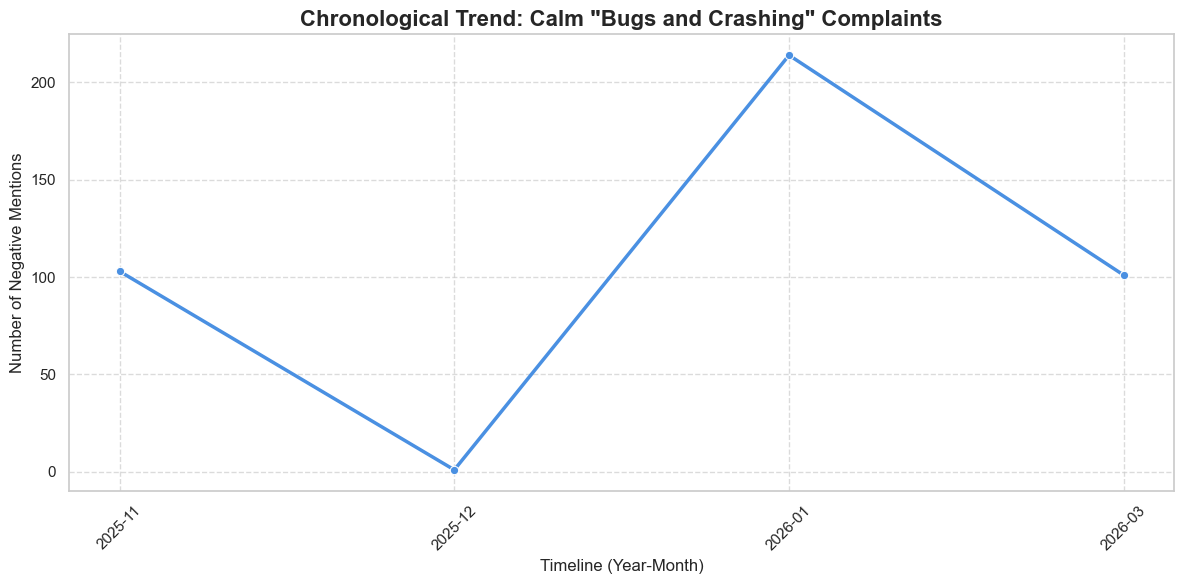

Chronological breakdown of Calm Bugs and Crashing mentions:
year_month
2025-11    103
2025-12      1
2026-01    214
2026-03    101
Name: count, dtype: int64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filtering the data for Calm's Negative Bug reviews
calm_bugs = absa_df[
    (absa_df['app_name'] == 'Calm') & 
    (absa_df['aspect'] == 'Bugs and Crashing') & 
    (absa_df['sentiment'] == 'Negative')
].copy()

# 2. Fixing the chronological sorting issue by creating a "Year-Month" column
def assign_year_month(month):
    m = int(month)
    # If it's a "large number" (e.g., later half of the year), it belongs to 2025
    if m > 6: 
        return f"2025-{m:02d}"  # Formats as 2025-11, 2025-12, etc.
    # Otherwise, it belongs to the new year, 2026
    else:
        return f"2026-{m:02d}"  # Formats as 2026-01, 2026-02, etc.

calm_bugs['year_month'] = calm_bugs['month_number'].apply(assign_year_month)

# 3. Counting the occurrences and sort by our new chronologically correct column
monthly_bug_counts = calm_bugs['year_month'].value_counts().sort_index()

# 4. Creating the Trend Chart
plt.figure(figsize=(12, 6))

# Using a nice blue color for Calm to differentiate from Headspace's orange
sns.lineplot(x=monthly_bug_counts.index, y=monthly_bug_counts.values, marker='o', color='#4A90E2', linewidth=2.5)

plt.title('Chronological Trend: Calm "Bugs and Crashing" Complaints', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Number of Negative Mentions', fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# Print the sorted data underneath to verify the order is correct
print("Chronological breakdown of Calm Bugs and Crashing mentions:")
print(monthly_bug_counts)

# Overview: App Stability & The Q1 Bug Surge

### The "New Year's Resolution" Effect

In January 2026, both Headspace and Calm experienced a notable spike in technical complaints. This aligns with the annual idea of a "New Year's Resolution" surge, where a massive influx of new and returning users places heavy stress on app servers, especially self-improvement apps. However, how the two companies handled this traffic tells completely different stories.

### Calm: Normal Traffic Stress & Quick Recovery

**The Surge:** Calm’s negative bug mentions roughly doubled during the January rush (from 103 in Nov to 214 in Jan).
**The Recovery:** By March, complaints dropped right back down to 101. Their development team successfully weathered the server strain and quickly stabilized the platform.

### Headspace: A Catastrophic Update & System Failure

**The Surge:** Headspace’s bug complaints exploded, jumping by over 5x (from 207 in Nov to an immense 1,095 in Jan).
**The Root Cause:** User reviews reveal this wasn't just server overload. Headspace made the critical error of pushing a major, deeply unpopular UI update right at their peak season. This update essentially broke the app, causing widespread crashes and usability issues just as traffic was at its highest.
**The Lingering Damage:** Unlike Calm, Headspace has not recovered. As of March 2026, they are still registering 531 bug complaints—more than double their normal baseline. This indicates that whatever the January update broke has still not been fully patched.

**Key Takeaway:** While Calm's app works as intended and handles scale well, Headspace is suffering from severe, persistent technical debt directly tied to a botched Q1 update.

# Overview: The "Billing Trap" and Pricing Frustrations

Regarding the aspects of Pricing, Refunds, and Customer Support: While the base cost of both apps is a common complaint, the raw data (1,379 negative mentions for Calm; 1,121 for Headspace) combined with user reviews reveals a much deeper issue: users feel actively deceived by the subscription mechanics. ***While users complain about the cost of both apps, this is a much more severe issue for Calm because it is their primary driver of negative sentiment.***

### 1. The "Bait and Switch" (Paywalls & Trials)

**The Free Trial Illusion:** A major driver of negative sentiment is the failure of the free trial system. Users across both apps report being charged immediately upon downloading, completely bypassing the promised trial period.
Headspace's Legacy Issue: Headspace suffers from a unique brand perception problem. Long-term users resent that the app, which once offered substantial free content, has locked almost everything behind a strict paywall.

### 2. Predatory Auto-Renewals & High-Friction Cancellations

**Silent Renewals:** Users are highly frustrated by the total lack of auto-renewal notifications.
The Cancellation Maze: Both apps make the cancellation process notoriously difficult. Worse, users report successfully navigating the cancellation process only to be charged anyway, indicating either broken backend systems or intentionally deceptive UI.

### 3. The Customer Service Wall (Refunds & Run-arounds)

**Inflexible Policies:** When users are hit with unexpected charges (sometimes just hours after a trial ends), their refund requests are systematically denied due to overly strict corporate policies.
**The Third-Party Run-around:** Customer support is described as lagging and unhelpful, heavily relying on the "App Store vs. Direct Billing" loophole. Users are bounced between Apple/Google Play support and the app's direct customer service, with neither side taking responsibility for issuing the refund.

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

In [22]:
import pandas as pd

# I'm using '\b' to specify word boundaries. 
# This means 'ai' will only match the exact word "ai", not "paid" or "said".
ai_keywords_regex = r'\b(ai|bot|artificial intelligence|therapy|clinical)\b'

# Filtering using the new regex pattern
headspace_ai_backlash = absa_df[
    (absa_df['app_name'] == 'Headspace') & 
    (absa_df['sentiment'] == 'Negative') &
    (absa_df['reason'].str.contains(ai_keywords_regex, case=False, na=False, regex=True) | 
     absa_df['aspect'].str.contains(ai_keywords_regex, case=False, na=False, regex=True))
].copy()

# Printing the top 15 reasons to find good quotes
print(f"Total AI/Therapy Negative Mentions Found: {len(headspace_ai_backlash)}\n")
print("Sample of User Feedback on AI/Therapy:")
print("-" * 50)

for index, row in headspace_ai_backlash.head(15).iterrows():
    print(f"Aspect: {row['aspect']}")
    print(f"Reason/Quote: {row['reason']}")
    print("-" * 50)


Total AI/Therapy Negative Mentions Found: 228

Sample of User Feedback on AI/Therapy:
--------------------------------------------------
Aspect: Ads
Reason/Quote: The reviewer expresses annoyance at being forced to engage with AI/therapy options that they are not interested in.
--------------------------------------------------
Aspect: Ads
Reason/Quote: The user finds the constant advertising for therapy and AI-powered services to be inappropriate and disruptive to the app's intended peaceful experience.
--------------------------------------------------
Aspect: Ads
Reason/Quote: The user expresses dissatisfaction with the push towards AI and counseling instead of focusing on meditation.
--------------------------------------------------
Aspect: Ads
Reason/Quote: The user expresses dissatisfaction with the presence of ads for therapy on app launch.
--------------------------------------------------
Aspect: Ads
Reason/Quote: The user is tired of closing pop-ups and did not subscribe for

/var/folders/w8/_82l_yz11k5f64zs4z94zylr0000gn/T/ipykernel_75938/536860174.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (absa_df['reason'].str.contains(ai_keywords_regex, case=False, na=False, regex=True) |
/var/folders/w8/_82l_yz11k5f64zs4z94zylr0000gn/T/ipykernel_75938/536860174.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  absa_df['aspect'].str.contains(ai_keywords_regex, case=False, na=False, regex=True))


# Emerging Risks: Headspace’s AI & Therapy Pivot

While technical stability and billing were the highest-volume complaints, qualitative and quantitative review analysis revealed a significant, emerging risk for Headspace: user backlash against the introduction of AI and the aggressive push toward in-app therapy.

# The Counterweight: Profound Real-World Impact

While financial and technical frustrations dominate the negative feedback, the positive sentiment is driven by deeply emotional, high-stakes outcomes.

**Mental Health & Crisis Intervention:** Users explicitly credit both apps with managing severe anxiety, depression, trauma, and loneliness.
**Interpersonal & Professional Growth:** The apps aren't just for solitary meditation; users report tangible improvements in how they navigate workplace stress and their relationships with friends and family.
**Generational Impact:** The inclusion of kids' content is a massive win, helping parents bring peace to their children.
**Sleep as a Superpower:** Improved sleep is frequently cited as a foundational change that ripples out into the rest of their lives.

***Calm's overwhelming lead in this specific category (976 mentions vs. Headspace's 292) suggests that Calm's specific approach to content and branding resonates on a deeper emotional level with its user base.***

### Methodology Note: Why ABSA?

Initial macro-level topic modeling (BERTopic) successfully identified broad themes but struggled with the high volume of mixed-sentiment reviews. By deploying an LLM-driven Aspect-Based Sentiment Analysis pipeline, we were able to surgically extract exact features. This allowed us to separate the immense value of Calm's content from its pricing complaints, and to quantify the exact severity of Headspace's technical collapse.

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)

# RQ3: What are the core user needs that drive users to these apps, and how effectively is each app succeeding or failing in addressing them?

# Value vs. Usability: A Comparative Analysis of Calm and Headspace from ABSA

This report analyzes recent user sentiment across the two leading mental health and mindfulness applications: Calm and Headspace. By utilizing advanced Aspect-Based Sentiment Analysis (ABSA), I extracted highly granular, feature-specific sentiment. The data reveals a stark contrast in where these apps are failing their users.

Calm consistently delivers profound, life-changing benefits, but faces immense friction due to high perceived costs and aggressive refund policies. Headspace, conversely, is experiencing a catastrophic technical breakdown, rendering the app virtually unusable and driving severe churn among long-time, paying users.

### Key Finding 1: Calm – Deep Impact, High Cost Barriers

Calm remains the dominant force in core product value, **vastly outperforming Headspace in "Life Improvement" (976 positive mentions vs. 292).** Users report profound positive impacts on sleep, trauma management, and daily anxiety.

However, this high value comes with significant user friction divided into two distinct camps:

**Sticker Shock (Pricing - 775 negative mentions):** The overwhelming majority of negative sentiment is simply frustration over the high cost of the app or disappointment that core features are not free.
**Damaged Trust (Refunds & Support - 604 combined negative mentions):** For users who do subscribe and attempt to cancel, Calm's strict refund policies and difficult customer support loop create a strong "billing trap" narrative, actively eroding brand trust.

### Key Finding 2: Headspace – Technical Collapse & Long-Term User Churn

While Headspace features **strong positive sentiment around its core "Content" (440 mentions),** the app is currently in a state of technical crisis that is actively destroying its subscriber base.

**The Unusable App:** Headspace suffered a massive spike in "Bugs and Crashing" (1,837 total mentions). This is not just a minor glitch; users report the app is literally unusable. Constant crashing and unresolved technical debt are forcing long-time, loyal users to abandon the platform because they are paying for a subscription with absolutely nothing to show for it.
**The Emerging AI Risk:** Compounding the technical failures is Headspace’s pivot toward clinical, AI-driven therapy, which is generating active backlash (154 specific negative mentions). Users explicitly state they are seeking an escape from screens and bots; introducing AI into a broken app environment is only accelerating user alienation.

### Strategic Recommendations

**For Calm:**

**Re-evaluate the Top-of-Funnel:** Address the massive "Pricing" friction by either introducing a more robust free tier or clearly communicating the premium value proposition earlier in the user journey.
**Overhaul Support Policies:** Soften the refund and cancellation UX to stop converting satisfied short-term users into angry detractors.

**For Headspace:**

**Emergency Code Freeze:** Halt all new feature shipping immediately. The primary objective must be patching the underlying causes of the crashes. Retention is currently impossible when the product does not open.
**Re-evaluate the AI Pivot:** The data shows clear friction regarding AI in a mindfulness context. Headspace must prioritize foundational stability before pushing controversial, automated clinical features to an already frustrated user base.

[Back to top](#Mindfulness-and-User-Experience-Using-Calm-And-Headspace)